In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# PATHS — one CSV per wave, produced by individual notebooks
# ============================================================

WAVE_PATHS = {
    1987: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/1987_Individual Unit_file/ICPSR_09484 4/cog1987_muni_real_percap.csv",
    1992: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/1992_Individual_Unit_File/cog1992_muni_real_percap.csv",
    1997: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/1997_Individual_Unit_file/cog1997_muni_real_percap.csv",
    2002: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/2002_Individual Unit_file/cog2002_muni_real_percap.csv",
    2012: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/2012_Individual_Unit_file (1)/cog2012_muni_real_percap.csv",
    2017: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/2017_Individual_Unit_File (1)/cog2017_muni_real_percap.csv",
    2022: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/2022_Individual_Unit_File/cog2022_muni_real_percap.csv",
}


In [80]:
waves = []
for year, path in WAVE_PATHS.items():
    df = pd.read_csv(path, dtype={"PLACE_ID": str})
    df["year"] = year
    waves.append(df)
    print(f"{year}: {len(df):,} rows, {df['PLACE_ID'].nunique():,} unique places")

panel = pd.concat(waves, ignore_index=True)

print(f"\nTotal rows: {len(panel):,}")
print(f"Unique places: {panel['PLACE_ID'].nunique():,}")
print(f"Years: {sorted(panel['year'].unique())}")


1987: 21,554 rows, 21,554 unique places
1992: 35,771 rows, 23,883 unique places
1997: 35,097 rows, 32,796 unique places
2002: 29,283 rows, 27,629 unique places
2012: 35,220 rows, 32,895 unique places
2017: 34,746 rows, 32,499 unique places
2022: 34,069 rows, 31,913 unique places

Total rows: 225,740
Unique places: 34,120
Years: [1987, 1992, 1997, 2002, 2012, 2017, 2022]


In [81]:
panel.year.unique()

array([1987, 1992, 1997, 2002, 2012, 2017, 2022])

In [89]:

# ============================================================
# PREP REGRESSION DATASET
# ============================================================

reg_df = panel.copy()

for col in ["federal_transfers_pc", "tax_revenue_pc", "is_split", "dist1_share", "dist1_pvi"]:
    reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")

reg_df["year"]     = reg_df["year"].astype(int)
reg_df["PLACE_ID"] = reg_df["PLACE_ID"].astype(str)

# Log outcomes — replace 0 with NaN before logging
reg_df["log_transfers_pc"] = np.log(reg_df["federal_transfers_pc"].replace(0, np.nan))
reg_df["log_tax_pc"]       = np.log(reg_df["tax_revenue_pc"].replace(0, np.nan))

reg_df["treatment_binary"] = reg_df["is_split"].astype(float)
reg_df["treatment_cont"]   = reg_df["dist1_share"].astype(float)

reg_df = reg_df.dropna(subset=["PLACE_ID", "year"])

baseline_yr = 2012
event_years = [y for y in sorted(reg_df["year"].unique()) if y != baseline_yr]

print(f"\nBaseline year: {baseline_yr}")
print(f"Event years:   {event_years}")
print(f"Sample size:   {len(reg_df):,}")



Baseline year: 2012
Event years:   [1987, 1992, 1997, 2002, 2017, 2022]
Sample size:   225,740


In [5]:

# ============================================================
# COVERAGE CHECK
# ============================================================

print("\nPlaces per year:")
print(reg_df.groupby("year")["PLACE_ID"].nunique().sort_index())

year_counts = reg_df.groupby("PLACE_ID")["year"].nunique()
print(f"\nPlaces in all 6 years: {(year_counts == 6).sum():,}")
print(f"Places in 5+ years:    {(year_counts >= 5).sum():,}")
print(f"Places in 4+ years:    {(year_counts >= 4).sum():,}")

# ============================================================
# SUMMARY STATS
# ============================================================

summary_cols = [c for c in [
    "federal_transfers_pc", "tax_revenue_pc",
    "log_transfers_pc", "log_tax_pc",
    "is_split", "dist1_share", "dist1_pvi",
] if c in reg_df.columns]

stats = reg_df[summary_cols].describe().T
stats["missing"] = reg_df[summary_cols].isna().sum()
stats = stats[["count","mean","std","min","25%","50%","75%","max","missing"]]
stats.columns = ["N","Mean","Std","Min","p25","Median","p75","Max","Missing"]
print("\n" + "="*90)
print("SUMMARY STATISTICS")
print("="*90)
print(stats.round(3).to_string())
print("="*90)


Places per year:
year
1987    21554
1992    23884
1997    32796
2002    27629
2012    32895
2017    32499
2022    31913
Name: PLACE_ID, dtype: int64

Places in all 6 years: 6,249
Places in 5+ years:    30,028
Places in 4+ years:    32,504

SUMMARY STATISTICS
                             N     Mean       Std      Min      p25   Median      p75          Max  Missing
federal_transfers_pc  172892.0   45.937   373.249  -43.488    0.000    0.000    9.147    60629.630    52848
tax_revenue_pc        224241.0  476.906  5231.152 -253.085  112.335  228.990  444.263  1724596.953     1499
log_transfers_pc       56379.0    3.431     1.794   -4.364    2.327    3.743    4.546       11.013   169361
log_tax_pc            223550.0    5.380     1.166   -3.010    4.729    5.437    6.099       14.361     2190
is_split              188960.0    0.036     0.187    0.000    0.000    0.000    0.000        1.000    36780
dist1_share           188937.0    0.985     0.071    0.033    1.000    1.000    1.000       

In [6]:
for yr in sorted(reg_df["year"].unique()):
    sub = reg_df[reg_df["year"] == yr]
    print(f"{yr}: {len(sub):,} rows | "
          f"log_transfers_pc missing: {sub['log_transfers_pc'].isna().sum():,} | "
          f"log_tax_pc missing: {sub['log_tax_pc'].isna().sum():,} | "
          f"treatment_binary missing: {sub['treatment_binary'].isna().sum():,} | "
          f"treatment_cont missing: {sub['treatment_cont'].isna().sum():,}")

1987: 21,554 rows | log_transfers_pc missing: 17,166 | log_tax_pc missing: 420 | treatment_binary missing: 0 | treatment_cont missing: 11
1992: 35,771 rows | log_transfers_pc missing: 30,536 | log_tax_pc missing: 923 | treatment_binary missing: 9,692 | treatment_cont missing: 9,694
1997: 35,097 rows | log_transfers_pc missing: 27,230 | log_tax_pc missing: 62 | treatment_binary missing: 5,918 | treatment_cont missing: 5,921
2002: 29,283 rows | log_transfers_pc missing: 22,342 | log_tax_pc missing: 568 | treatment_binary missing: 4,499 | treatment_cont missing: 4,500
2012: 35,220 rows | log_transfers_pc missing: 26,028 | log_tax_pc missing: 65 | treatment_binary missing: 5,733 | treatment_cont missing: 5,735
2017: 34,746 rows | log_transfers_pc missing: 27,085 | log_tax_pc missing: 41 | treatment_binary missing: 5,573 | treatment_cont missing: 5,575
2022: 34,069 rows | log_transfers_pc missing: 18,974 | log_tax_pc missing: 111 | treatment_binary missing: 5,365 | treatment_cont missing: 5

In [7]:
for yr in sorted(reg_df["year"].unique()):
    sub = reg_df[reg_df["year"] == yr]
    print(f"{yr}: {len(sub):,} rows | "
          f"log_transfers_pc missing: {sub['log_transfers_pc'].isna().sum():,} | "
          f"log_tax_pc missing: {sub['log_tax_pc'].isna().sum():,} | "
          f"treatment_binary missing: {sub['treatment_binary'].isna().sum():,} | "
          f"treatment_cont missing: {sub['treatment_cont'].isna().sum():,}")

1987: 21,554 rows | log_transfers_pc missing: 17,166 | log_tax_pc missing: 420 | treatment_binary missing: 0 | treatment_cont missing: 11
1992: 35,771 rows | log_transfers_pc missing: 30,536 | log_tax_pc missing: 923 | treatment_binary missing: 9,692 | treatment_cont missing: 9,694
1997: 35,097 rows | log_transfers_pc missing: 27,230 | log_tax_pc missing: 62 | treatment_binary missing: 5,918 | treatment_cont missing: 5,921
2002: 29,283 rows | log_transfers_pc missing: 22,342 | log_tax_pc missing: 568 | treatment_binary missing: 4,499 | treatment_cont missing: 4,500
2012: 35,220 rows | log_transfers_pc missing: 26,028 | log_tax_pc missing: 65 | treatment_binary missing: 5,733 | treatment_cont missing: 5,735
2017: 34,746 rows | log_transfers_pc missing: 27,085 | log_tax_pc missing: 41 | treatment_binary missing: 5,573 | treatment_cont missing: 5,575
2022: 34,069 rows | log_transfers_pc missing: 18,974 | log_tax_pc missing: 111 | treatment_binary missing: 5,365 | treatment_cont missing: 5

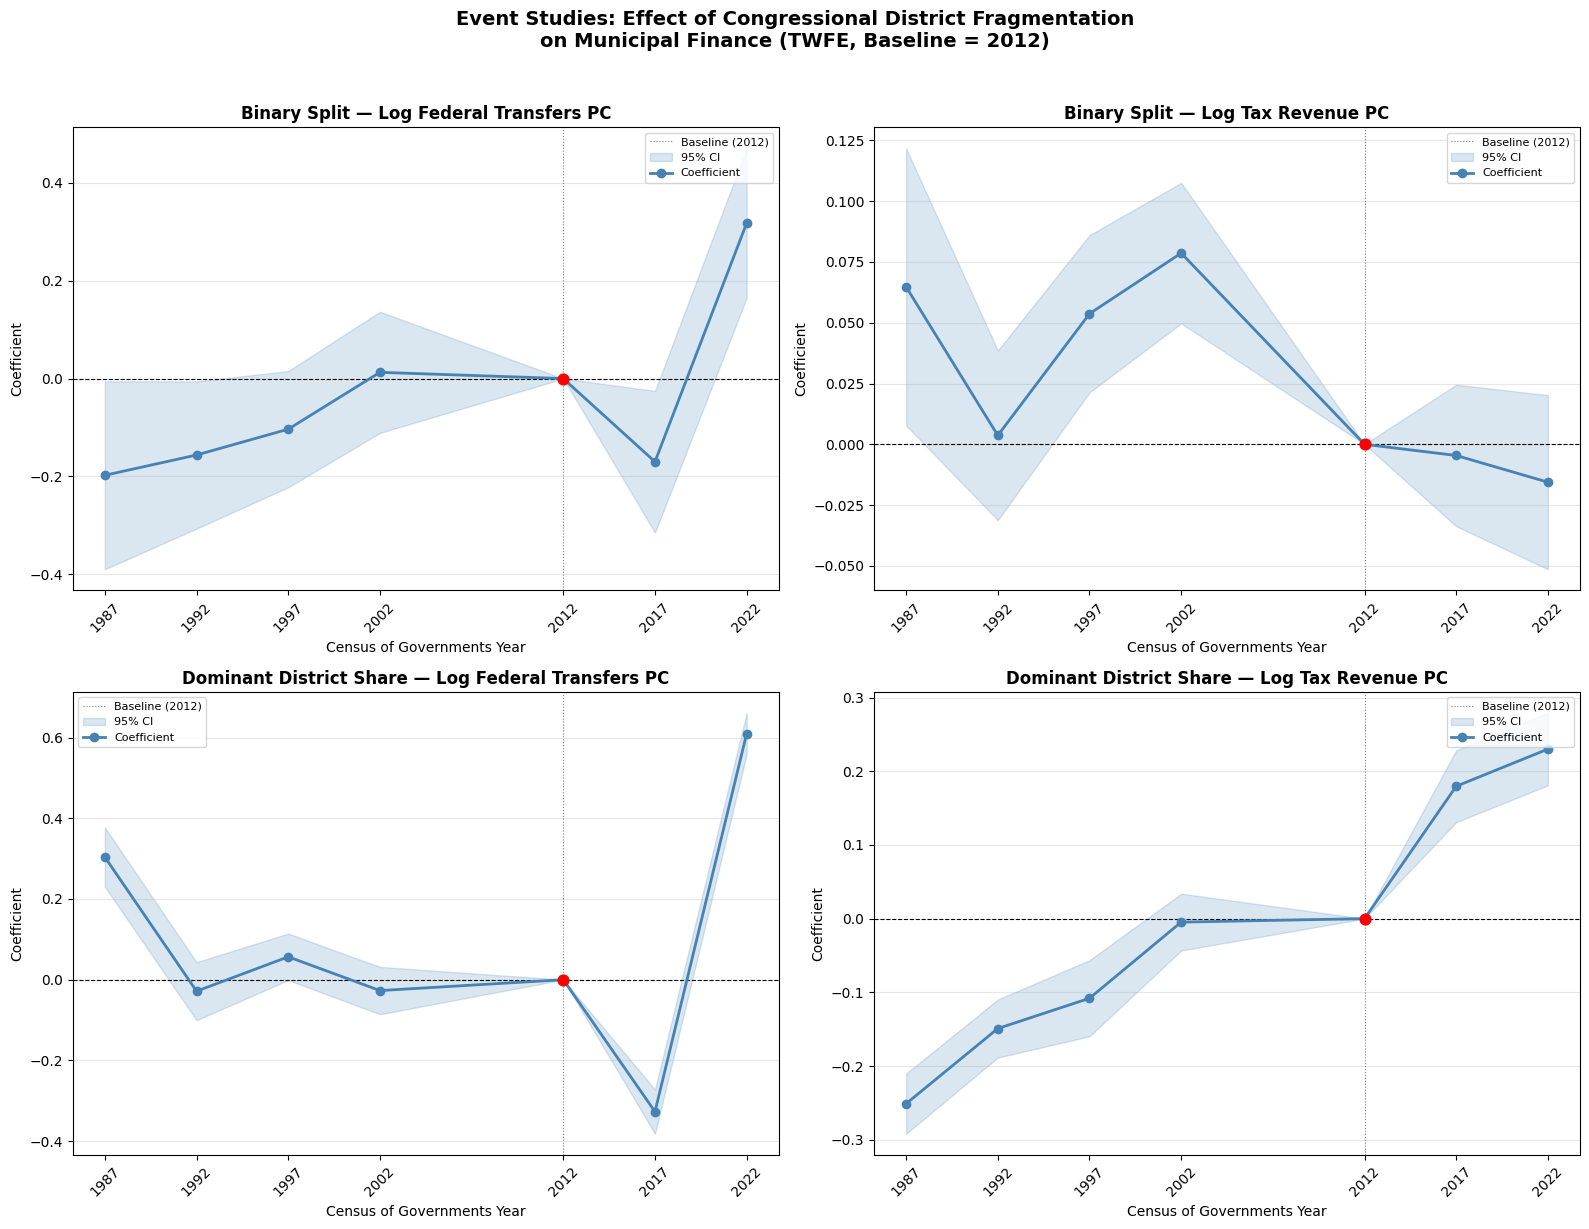


EVENT STUDY: Binary Split — Log Federal Transfers PC
Baseline: 2012
---------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi
---------------------------------------------------------------------------
  1987     -0.1977      0.0980     -2.02    0.0436     -0.3898     -0.0057  **
  1992     -0.1562      0.0768     -2.04    0.0418     -0.3067     -0.0058  **
  1997     -0.1035      0.0606     -1.71    0.0879     -0.2223      0.0154  *
  2002      0.0128      0.0632      0.20    0.8400     -0.1111      0.1366  
  2012      0.0000      0.0000       nan       nan      0.0000      0.0000   <- baseline
  2017     -0.1700      0.0739     -2.30    0.0214     -0.3149     -0.0252  **
  2022      0.3177      0.0780      4.08    0.0000      0.1649      0.4705  ***

EVENT STUDY: Binary Split — Log Tax Revenue PC
Baseline: 2012
---------------------------------------------------------------------------
  Ye

In [8]:


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def within_demean(df, col, group):
    return df[col] - df.groupby(group)[col].transform("mean")

def run_event_study(df, outcome_col, treatment_col, baseline_yr):
    d = df.dropna(subset=[outcome_col, treatment_col, "PLACE_ID", "year"]).copy()
    d[treatment_col] = pd.to_numeric(d[treatment_col], errors="coerce")
    d = d.dropna(subset=[treatment_col])

    yrs = [y for y in sorted(d["year"].unique()) if y != baseline_yr]

    for yr in yrs:
        d[f"tx{yr}"] = d[treatment_col] * (d["year"] == yr).astype(float)

    cols = [outcome_col, treatment_col] + [f"tx{yr}" for yr in yrs]
    for col in cols:
        d[f"dm_{col}"] = within_demean(d, col, "PLACE_ID")
    for col in cols:
        d[f"dm_{col}"] = within_demean(d, f"dm_{col}", "year")

    terms   = " + ".join([f"dm_tx{yr}" for yr in yrs])
    formula = f"dm_{outcome_col} ~ {terms} - 1"

    model = smf.ols(formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["PLACE_ID"]}
    )

    coef_df = pd.DataFrame({
        "year": yrs,
        "coef": [model.params.get(f"dm_tx{yr}", np.nan) for yr in yrs],
        "se":   [model.bse.get(f"dm_tx{yr}", np.nan) for yr in yrs],
    })
    coef_df = pd.concat([
        coef_df,
        pd.DataFrame({"year": [baseline_yr], "coef": [0.0], "se": [0.0]})
    ]).sort_values("year").reset_index(drop=True)
    coef_df["ci_lo"] = coef_df["coef"] - 1.96 * coef_df["se"]
    coef_df["ci_hi"] = coef_df["coef"] + 1.96 * coef_df["se"]
    return coef_df, model

def plot_event_study(coef_df, title, ax, baseline_yr):
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(baseline_yr, color="gray", linewidth=0.8,
               linestyle=":", label=f"Baseline ({baseline_yr})")
    ax.fill_between(coef_df["year"], coef_df["ci_lo"], coef_df["ci_hi"],
                    alpha=0.2, color="steelblue", label="95% CI")
    ax.plot(coef_df["year"], coef_df["coef"],
            color="steelblue", marker="o", linewidth=2,
            markersize=6, label="Coefficient")
    ax.scatter([baseline_yr], [0], color="red", zorder=5, s=60)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Census of Governments Year", fontsize=10)
    ax.set_ylabel("Coefficient", fontsize=10)
    ax.xaxis.set_major_locator(
        mticker.FixedLocator(sorted(coef_df["year"].tolist()))
    )
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

def print_coef_table(coef_df, label, baseline_yr):
    from scipy.stats import norm
    print("\n" + "="*75)
    print(f"EVENT STUDY: {label}")
    print(f"Baseline: {baseline_yr}")
    print("-"*75)
    print(f"{'Year':>6}  {'Coef':>10}  {'SE':>10}  {'t':>8}  {'p':>8}  {'CI Lo':>10}  {'CI Hi':>10}")
    print("-"*75)
    for _, row in coef_df.iterrows():
        yr   = int(row["year"])
        coef = row["coef"]
        se   = row["se"]
        t    = coef / se if se > 0 else np.nan
        p    = 2 * (1 - norm.cdf(abs(t))) if not np.isnan(t) else np.nan
        stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
        base = " <- baseline" if yr == baseline_yr else ""
        print(f"  {yr:>4}  {coef:>10.4f}  {se:>10.4f}  {t:>8.2f}  {p:>8.4f}  {row['ci_lo']:>10.4f}  {row['ci_hi']:>10.4f}  {stars}{base}")
    print("="*75)

# ============================================================
# RUN EVENT STUDIES
# ============================================================

coef_binary_transfers, _ = run_event_study(reg_df, "log_transfers_pc", "treatment_binary", baseline_yr)
coef_binary_tax,       _ = run_event_study(reg_df, "log_tax_pc",       "treatment_binary", baseline_yr)
coef_cont_transfers,   _ = run_event_study(reg_df, "log_transfers_pc", "treatment_cont",   baseline_yr)
coef_cont_tax,         _ = run_event_study(reg_df, "log_tax_pc",       "treatment_cont",   baseline_yr)

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_event_study(coef_binary_transfers, "Binary Split — Log Federal Transfers PC",       axes[0,0], baseline_yr)
plot_event_study(coef_binary_tax,       "Binary Split — Log Tax Revenue PC",              axes[0,1], baseline_yr)
plot_event_study(coef_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", axes[1,0], baseline_yr)
plot_event_study(coef_cont_tax,         "Dominant District Share — Log Tax Revenue PC",   axes[1,1], baseline_yr)

fig.suptitle(
    "Event Studies: Effect of Congressional District Fragmentation\n"
    "on Municipal Finance (TWFE, Baseline = 2012)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

# ============================================================
# PRINT COEFFICIENT TABLES
# ============================================================

print_coef_table(coef_binary_transfers, "Binary Split — Log Federal Transfers PC",       baseline_yr)
print_coef_table(coef_binary_tax,       "Binary Split — Log Tax Revenue PC",              baseline_yr)
print_coef_table(coef_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", baseline_yr)
print_coef_table(coef_cont_tax,         "Dominant District Share — Log Tax Revenue PC",   baseline_yr)

In [113]:
# ============================================================
# SIZE BINS — based on 2002 population as reference year
# ============================================================

pop_2002 = reg_df[reg_df['year'] == 2002][['PLACE_ID', 'population']].copy()
pop_2002 = pop_2002.rename(columns={'population': 'pop_2002'})
pop_2002['pop_2002'] = pd.to_numeric(pop_2002['pop_2002'], errors='coerce')
pop_2002 = pop_2002.dropna(subset=['pop_2002']).drop_duplicates(subset='PLACE_ID')

reg_df = reg_df.merge(pop_2002, on='PLACE_ID', how='left')

def size_bin(pop):
    if pd.isna(pop):
        return 'unknown'
    elif pop < 25000:
        return 'small'
    elif pop < 100000:
        return 'medium'
    else:
        return 'large'

reg_df['size_bin'] = reg_df['pop_2002'].apply(size_bin)

print("Size bin distribution:")
print(reg_df[reg_df['year'] == 2002]['size_bin'].value_counts())

Size bin distribution:
size_bin
small     27738
medium     1270
large       275
Name: count, dtype: int64


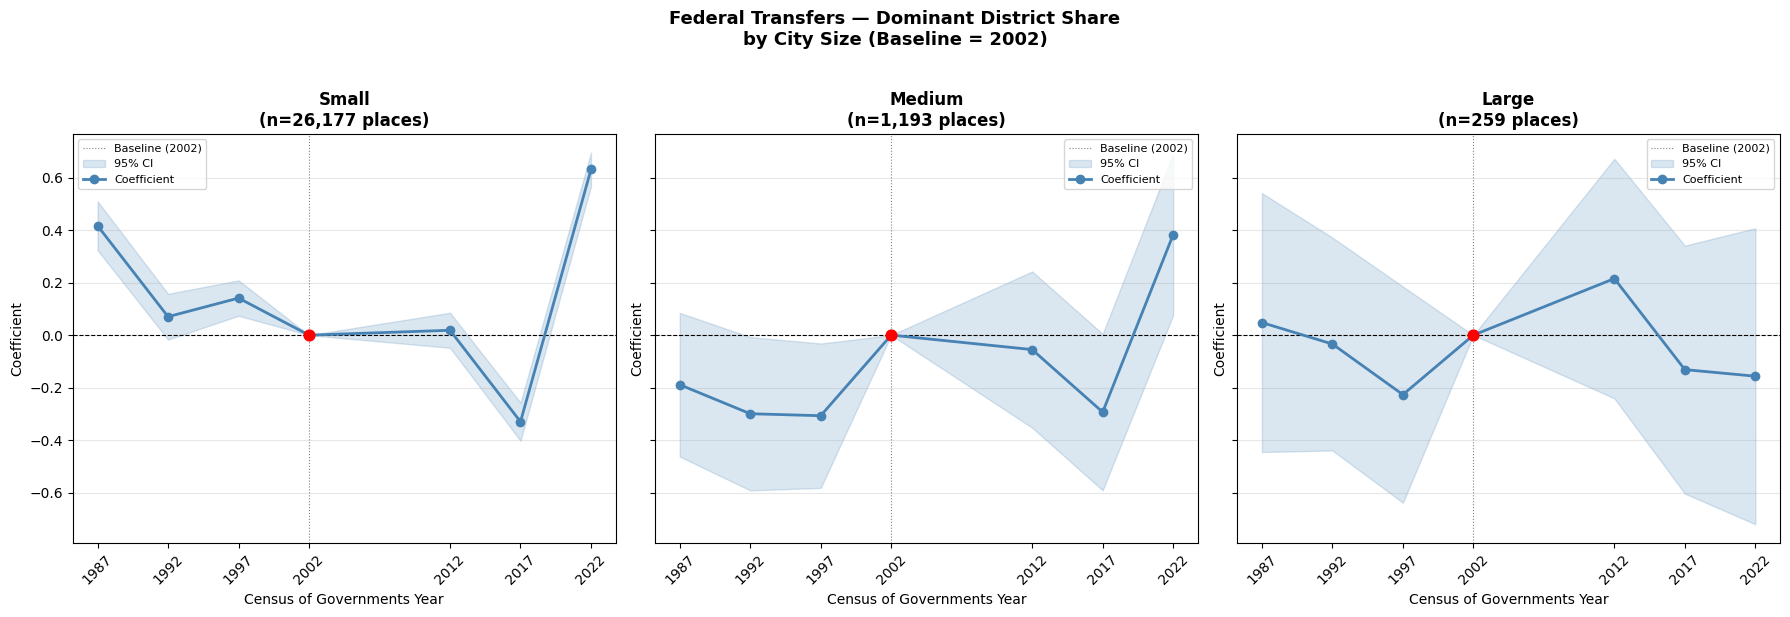

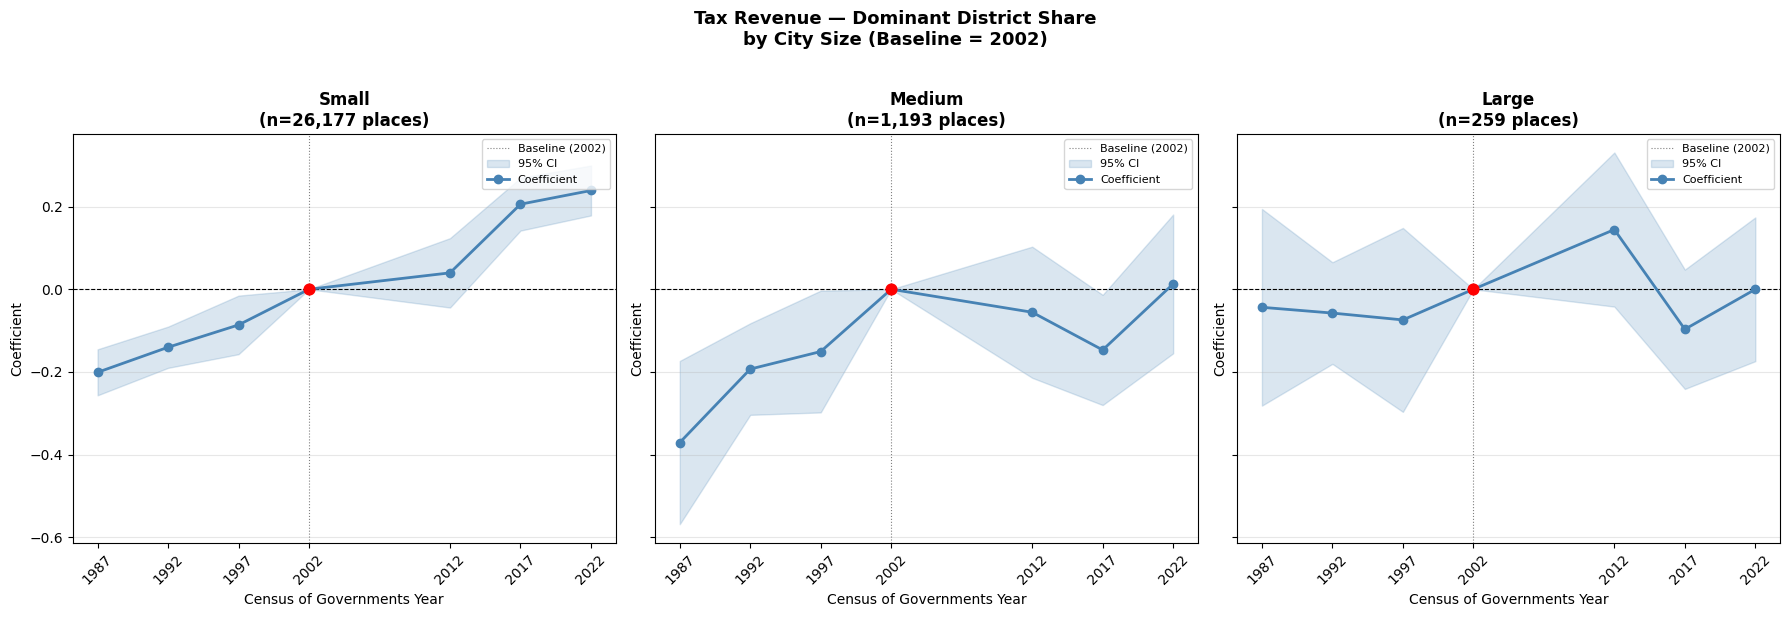


COEFFICIENT TABLES — Dominant District Share

EVENT STUDY: SMALL — Log Federal Transfers PC
Baseline: 2002
------------------------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi    % Effect    Sig
------------------------------------------------------------------------------------------
  1987      0.4169      0.0476      8.76    0.0000      0.3236      0.5101       23.2%  ***
  1992      0.0703      0.0445      1.58    0.1143     -0.0169      0.1575        3.6%  
  1997      0.1412      0.0344      4.11    0.0000      0.0738      0.2087        7.3%  ***
  2002      0.0000      0.0000       nan       nan      0.0000      0.0000        0.0%   <- baseline
  2012      0.0185      0.0341      0.54    0.5873     -0.0483      0.0853        0.9%  
  2017     -0.3301      0.0370     -8.92    0.0000     -0.4027     -0.2576      -15.2%  ***
  2022      0.6315      0.0330     19.14    0.0000      0.566

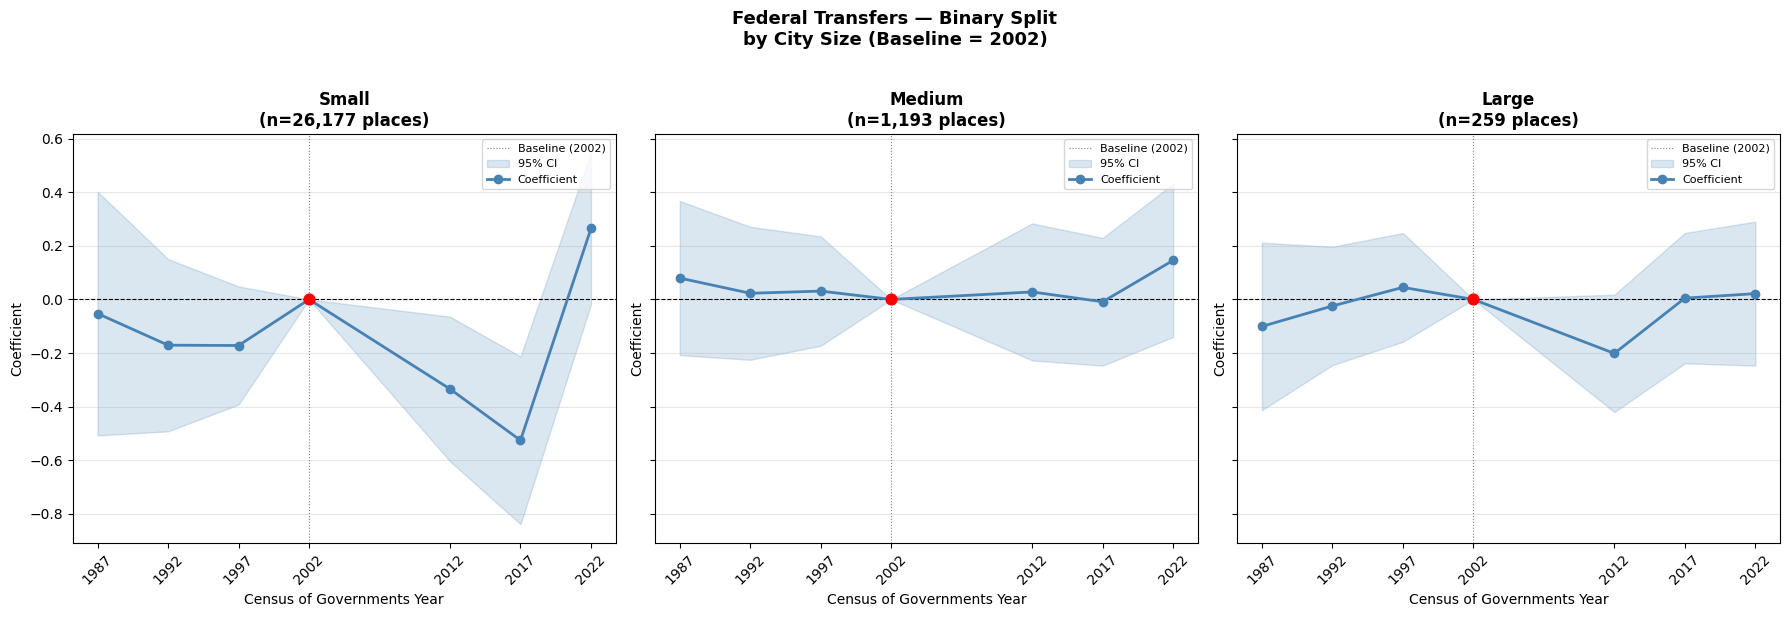

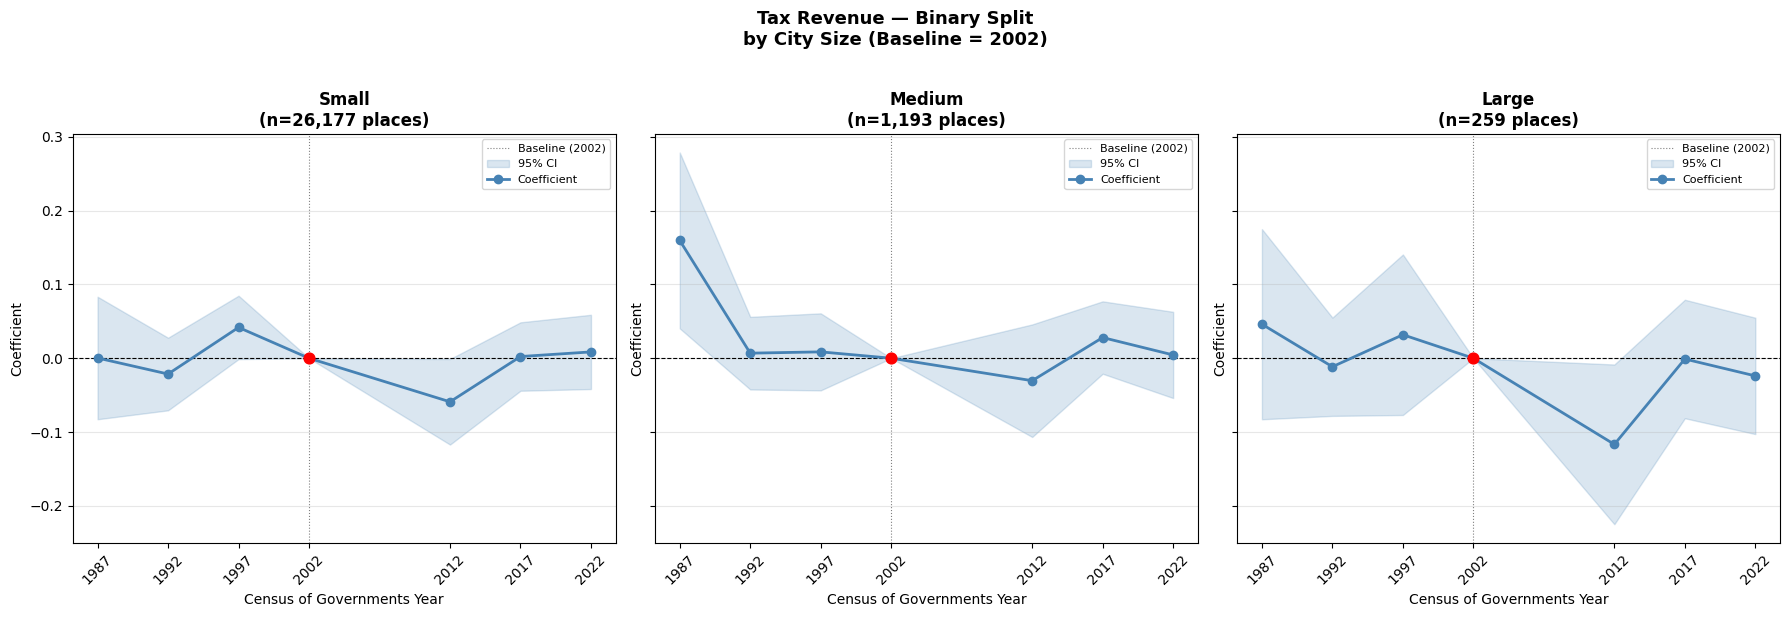


COEFFICIENT TABLES — Binary Split

EVENT STUDY: SMALL — Log Federal Transfers PC
Baseline: 2002
------------------------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi    % Effect    Sig
------------------------------------------------------------------------------------------
  1987     -0.0527      0.2320     -0.23    0.8203     -0.5074      0.4020       -2.6%  
  1992     -0.1707      0.1640     -1.04    0.2979     -0.4920      0.1507       -8.2%  
  1997     -0.1719      0.1124     -1.53    0.1262     -0.3922      0.0484       -8.2%  
  2002      0.0000      0.0000       nan       nan      0.0000      0.0000        0.0%   <- baseline
  2012     -0.3341      0.1376     -2.43    0.0152     -0.6039     -0.0643      -15.4%  **
  2017     -0.5257      0.1596     -3.29    0.0010     -0.8386     -0.2128      -23.1%  ***
  2022      0.2647      0.1446      1.83    0.0671     -0.0186      0.5480  

In [114]:
# ============================================================
# EVENT STUDIES BY SIZE BIN
# ============================================================

size_baseline = 2002
size_bins = ['small', 'medium', 'large']

for treatment, treatment_label in [('treatment_cont', 'Dominant District Share'), 
                                    ('treatment_binary', 'Binary Split')]:
    
    # ── Federal Transfers Figure ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    
    for ax, bin_name in zip(axes, size_bins):
        bin_df = reg_df[reg_df['size_bin'] == bin_name].copy()
        
        if bin_df[treatment].notna().sum() == 0:
            ax.set_title(f"{bin_name.capitalize()} (no data)")
            continue
        
        coef_df, _ = run_event_study(bin_df, 'log_transfers_pc', treatment, size_baseline)
        plot_event_study(coef_df, f"{bin_name.capitalize()}\n(n={bin_df['PLACE_ID'].nunique():,} places)", ax, size_baseline)
    
    fig.suptitle(
        f"Federal Transfers — {treatment_label}\nby City Size (Baseline = {size_baseline})",
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig(f"figure_size_transfers_{treatment}.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ── Tax Revenue Figure ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    
    for ax, bin_name in zip(axes, size_bins):
        bin_df = reg_df[reg_df['size_bin'] == bin_name].copy()
        
        if bin_df[treatment].notna().sum() == 0:
            ax.set_title(f"{bin_name.capitalize()} (no data)")
            continue
        
        coef_df, _ = run_event_study(bin_df, 'log_tax_pc', treatment, size_baseline)
        plot_event_study(coef_df, f"{bin_name.capitalize()}\n(n={bin_df['PLACE_ID'].nunique():,} places)", ax, size_baseline)
    
    fig.suptitle(
        f"Tax Revenue — {treatment_label}\nby City Size (Baseline = {size_baseline})",
        fontsize=13, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig(f"figure_size_tax_{treatment}.png", dpi=300, bbox_inches='tight')
    plt.show()

    # ── Coefficient Tables ────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"COEFFICIENT TABLES — {treatment_label}")
    print(f"{'='*60}")
    
    for bin_name in size_bins:
        bin_df = reg_df[reg_df['size_bin'] == bin_name].copy()
        
        coef_df, _ = run_event_study(bin_df, 'log_transfers_pc', treatment, size_baseline)
        print_coef_table(coef_df, f"{bin_name.upper()} — Log Federal Transfers PC", size_baseline)
        
        coef_df, _ = run_event_study(bin_df, 'log_tax_pc', treatment, size_baseline)
        print_coef_table(coef_df, f"{bin_name.upper()} — Log Tax Revenue PC", size_baseline)

Cities unified in 2002: 22,211
Of those, observed in 2012: 23,986
Became split by 2012: 431
Stayed unified in 2012: 23,555

DiD sample size: 212,877
Unique cities: 21,888
Treated (became split): 395
Control (stayed unified): 21,493

DiD baseline: 2002
DiD event years: [1987, 1992, 1997, 2012, 2017, 2022]


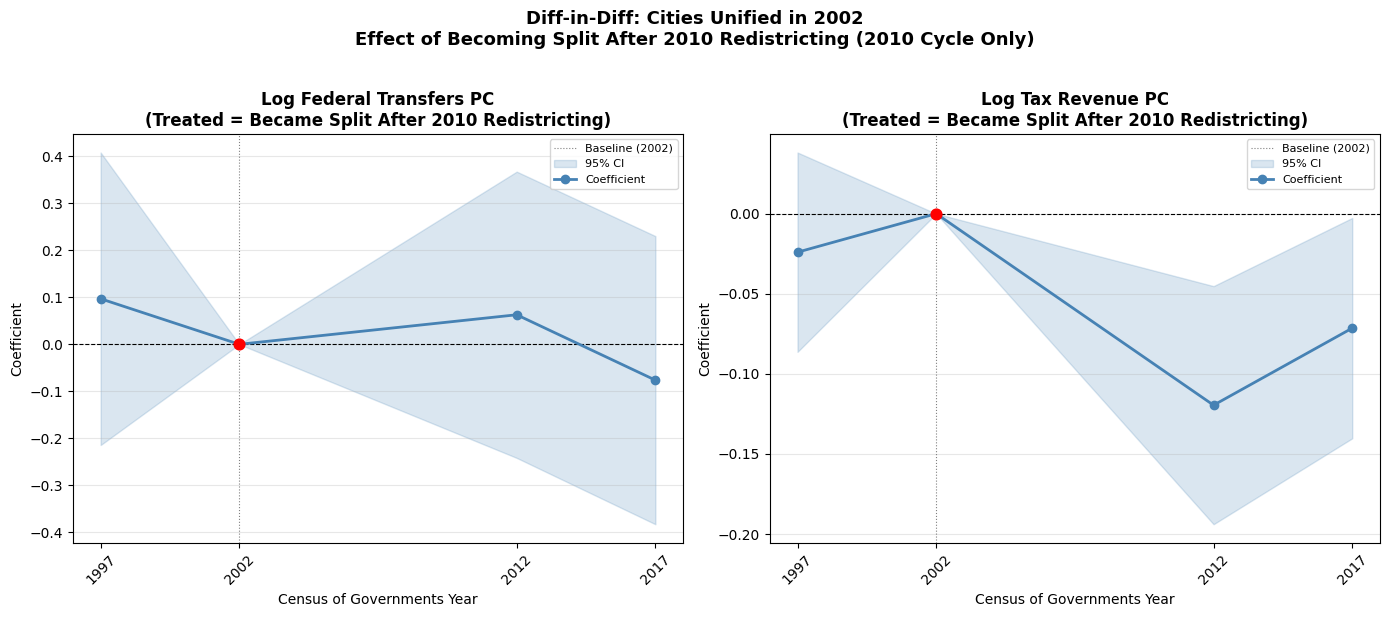


EVENT STUDY: DiD — Log Federal Transfers PC (2010 cycle)
Baseline: 2002
---------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi
---------------------------------------------------------------------------
  1997      0.0969      0.1588      0.61    0.5417     -0.2144      0.4083  
  2002      0.0000      0.0000       nan       nan      0.0000      0.0000   <- baseline
  2012      0.0629      0.1554      0.40    0.6858     -0.2418      0.3676  
  2017     -0.0763      0.1565     -0.49    0.6257     -0.3830      0.2303  

EVENT STUDY: DiD — Log Tax Revenue PC (2010 cycle)
Baseline: 2002
---------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi
---------------------------------------------------------------------------
  1997     -0.0240      0.0318     -0.76    0.4489     -0.0863      0.0382  
  2002   

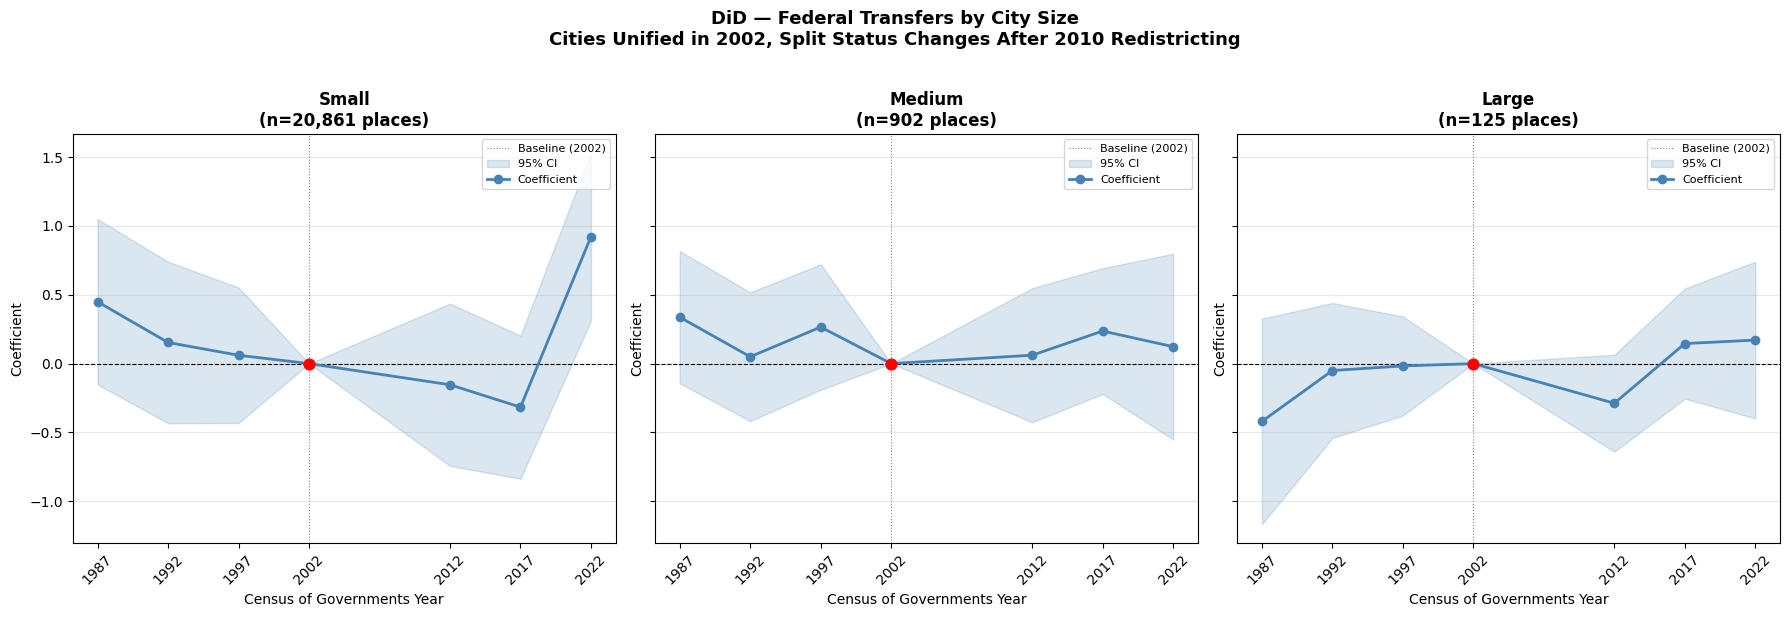

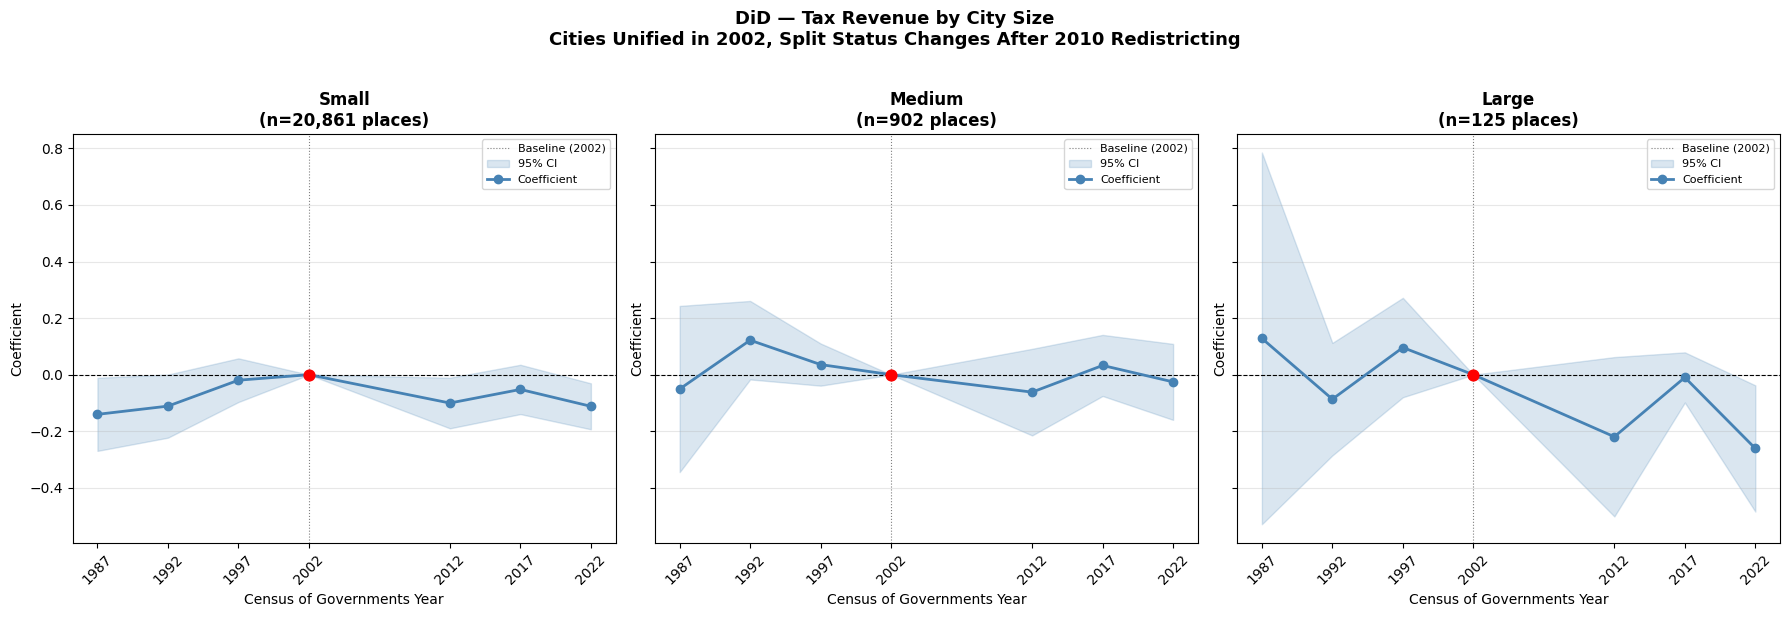


SMALL cities:
Unique places: 26,177
Split share: 0.028

Federal transfers coefficients:

EVENT STUDY: small — Log Federal Transfers PC
Baseline: 2012
---------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi
---------------------------------------------------------------------------
  1987      0.4048      0.0474      8.54    0.0000      0.3119      0.4977  ***
  1992      0.0582      0.0446      1.30    0.1923     -0.0293      0.1457  
  1997      0.1291      0.0349      3.70    0.0002      0.0608      0.1975  ***
  2002     -0.0053      0.0345     -0.15    0.8787     -0.0729      0.0624  
  2012      0.0000      0.0000       nan       nan      0.0000      0.0000   <- baseline
  2017     -0.3412      0.0339    -10.08    0.0000     -0.4076     -0.2749  ***
  2022      0.6196      0.0309     20.08    0.0000      0.5591      0.6801  ***

Tax revenue coefficients:

EVENT STUDY: small — Log Tax Re

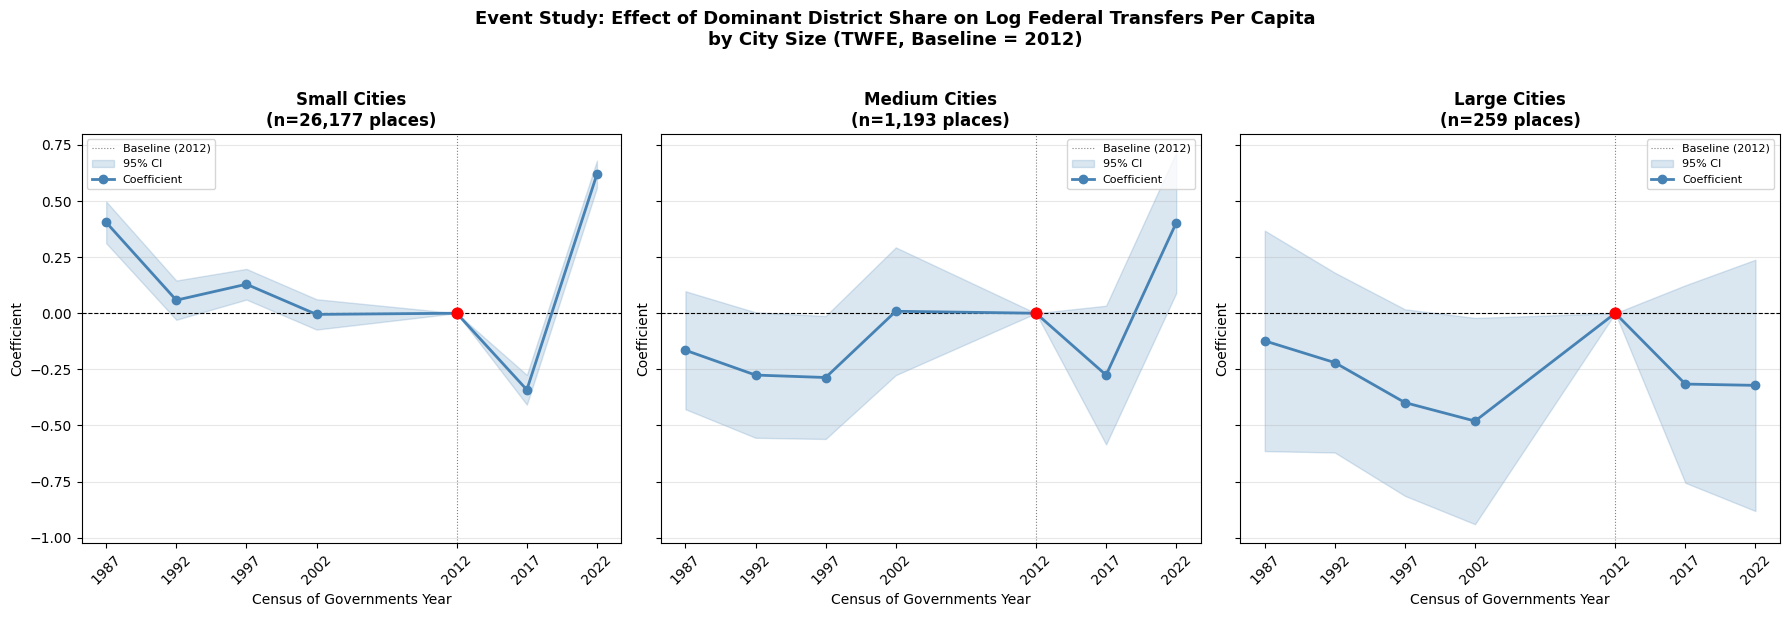

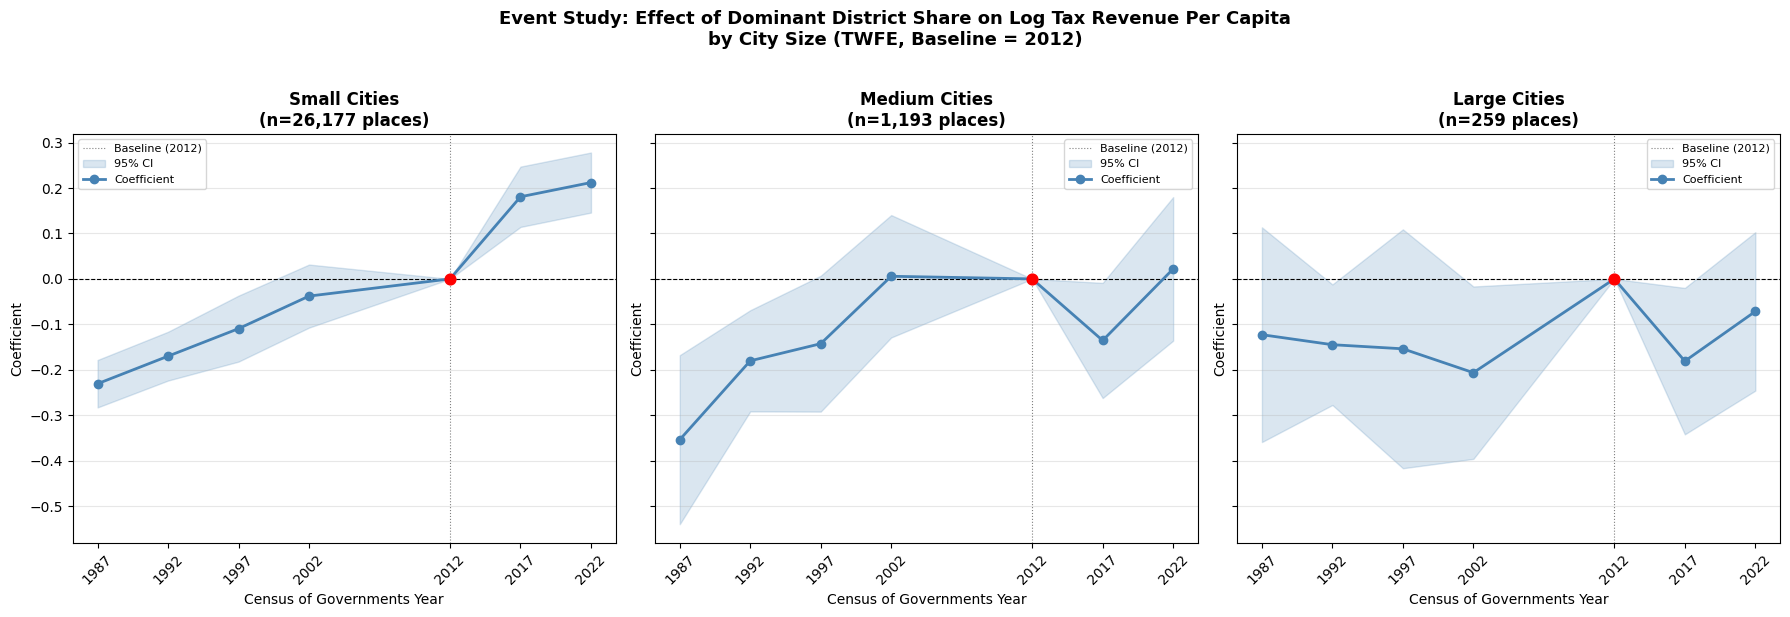

In [45]:
# ============================================================
# DIFF-IN-DIFF: CITIES UNIFIED IN 2002, SPLIT STATUS CHANGES IN 2012
# ============================================================

# Step 1: identify cities that were unified in 2002
unified_2002 = reg_df[
    (reg_df['year'] == 2002) & 
    (reg_df['is_split'] == 0)
]['PLACE_ID'].unique()

print(f"Cities unified in 2002: {len(unified_2002):,}")

# Step 2: identify their split status in 2012
status_2012 = reg_df[
    (reg_df['year'] == 2012) & 
    (reg_df['PLACE_ID'].isin(unified_2002))
][['PLACE_ID', 'is_split']].copy()
status_2012 = status_2012.rename(columns={'is_split': 'split_2012'})
status_2012['split_2012'] = pd.to_numeric(status_2012['split_2012'], errors='coerce')

print(f"Of those, observed in 2012: {len(status_2012):,}")
print(f"Became split by 2012: {(status_2012['split_2012'] == 1).sum():,}")
print(f"Stayed unified in 2012: {(status_2012['split_2012'] == 0).sum():,}")

# Step 3: build the DiD sample
# Keep only cities unified in 2002 that we observe in 2012
did_cities = status_2012.dropna(subset=['split_2012'])['PLACE_ID'].unique()

did_df = reg_df[reg_df['PLACE_ID'].isin(did_cities)].copy()

# Merge in the 2012 split status as the treatment indicator
did_df = did_df.merge(status_2012[['PLACE_ID', 'split_2012']], on='PLACE_ID', how='left')

# Treatment = became split by 2012
did_df['treated'] = did_df['split_2012'].astype(float)

# Post = 2012 or later
did_df['post'] = (did_df['year'] >= 2012).astype(float)

print(f"\nDiD sample size: {len(did_df):,}")
print(f"Unique cities: {did_df['PLACE_ID'].nunique():,}")
print(f"Treated (became split): {did_df[did_df['treated']==1]['PLACE_ID'].nunique():,}")
print(f"Control (stayed unified): {did_df[did_df['treated']==0]['PLACE_ID'].nunique():,}")

# ============================================================
# EVENT STUDY ON DiD SAMPLE
# ============================================================

# Use 2002 as baseline since that's the pre-period
did_baseline = 2002
did_event_years = [y for y in sorted(did_df['year'].unique()) if y != did_baseline]

print(f"\nDiD baseline: {did_baseline}")
print(f"DiD event years: {did_event_years}")

# Run event studies on DiD sample
coef_did_transfers, _ = run_event_study(did_df, 'log_transfers_pc', 'treated', did_baseline)
coef_did_tax,       _ = run_event_study(did_df, 'log_tax_pc',       'treated', did_baseline)

# ============================================================
# PLOT DiD EVENT STUDIES
# ============================================================

# Filter to 2010 redistricting cycle only
did_df_clean = did_df[did_df['year'].isin([1997, 2002, 2012, 2017])].copy()

did_baseline = 2002
did_event_years = [1997, 2012, 2017]

coef_did_transfers, _ = run_event_study(did_df_clean, 'log_transfers_pc', 'treated', did_baseline)
coef_did_tax,       _ = run_event_study(did_df_clean, 'log_tax_pc',       'treated', did_baseline)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_event_study(coef_did_transfers,
    "Log Federal Transfers PC\n(Treated = Became Split After 2010 Redistricting)",
    axes[0], did_baseline)
plot_event_study(coef_did_tax,
    "Log Tax Revenue PC\n(Treated = Became Split After 2010 Redistricting)",
    axes[1], did_baseline)

fig.suptitle(
    "Diff-in-Diff: Cities Unified in 2002\n"
    "Effect of Becoming Split After 2010 Redistricting (2010 Cycle Only)",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print_coef_table(coef_did_transfers, "DiD — Log Federal Transfers PC (2010 cycle)", did_baseline)
print_coef_table(coef_did_tax,       "DiD — Log Tax Revenue PC (2010 cycle)",       did_baseline)


# ============================================================
# DiD BY SIZE BIN
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, bin_name in zip(axes, ['small', 'medium', 'large']):
    bin_df = did_df[did_df['size_bin'] == bin_name].copy()
    if bin_df['treated'].notna().sum() == 0 or bin_df['PLACE_ID'].nunique() < 10:
        ax.set_title(f"{bin_name.capitalize()} (insufficient data)")
        continue
    coef_df, _ = run_event_study(bin_df, 'log_transfers_pc', 'treated', did_baseline)
    plot_event_study(
        coef_df,
        f"{bin_name.capitalize()}\n(n={bin_df['PLACE_ID'].nunique():,} places)",
        ax, did_baseline
    )

fig.suptitle(
    "DiD — Federal Transfers by City Size\n"
    "Cities Unified in 2002, Split Status Changes After 2010 Redistricting",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, bin_name in zip(axes, ['small', 'medium', 'large']):
    bin_df = did_df[did_df['size_bin'] == bin_name].copy()
    if bin_df['treated'].notna().sum() == 0 or bin_df['PLACE_ID'].nunique() < 10:
        ax.set_title(f"{bin_name.capitalize()} (insufficient data)")
        continue
    coef_df, _ = run_event_study(bin_df, 'log_tax_pc', 'treated', did_baseline)
    plot_event_study(
        coef_df,
        f"{bin_name.capitalize()}\n(n={bin_df['PLACE_ID'].nunique():,} places)",
        ax, did_baseline
    )

fig.suptitle(
    "DiD — Tax Revenue by City Size\n"
    "Cities Unified in 2002, Split Status Changes After 2010 Redistricting",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


for bin_name in ['small', 'medium', 'large']:
    bin_df = reg_df[reg_df['size_bin'] == bin_name].copy()
    print(f"\n{bin_name.upper()} cities:")
    print(f"Unique places: {bin_df['PLACE_ID'].nunique():,}")
    print(f"Split share: {bin_df[bin_df['year']==2002]['is_split'].mean():.3f}")
    
    coef_df, model = run_event_study(bin_df, 'log_transfers_pc', 'treatment_cont', baseline_yr)
    print("\nFederal transfers coefficients:")
    print_coef_table(coef_df, f"{bin_name} — Log Federal Transfers PC", baseline_yr)
    
    coef_df, model = run_event_study(bin_df, 'log_tax_pc', 'treatment_cont', baseline_yr)
    print("\nTax revenue coefficients:")
    print_coef_table(coef_df, f"{bin_name} — Log Tax Revenue PC", baseline_yr)





fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, bin_name in zip(axes, ['small', 'medium', 'large']):
    bin_df = reg_df[reg_df['size_bin'] == bin_name].copy()
    if bin_df['treatment_cont'].notna().sum() == 0:
        ax.set_title(f"{bin_name.capitalize()} (insufficient data)")
        continue
    coef_df, _ = run_event_study(bin_df, 'log_transfers_pc', 'treatment_cont', baseline_yr)
    plot_event_study(
        coef_df,
        f"{bin_name.capitalize()} Cities\n(n={bin_df['PLACE_ID'].nunique():,} places)",
        ax, baseline_yr
    )

fig.suptitle(
    "Event Study: Effect of Dominant District Share on Log Federal Transfers Per Capita\nby City Size (TWFE, Baseline = 2012)",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, bin_name in zip(axes, ['small', 'medium', 'large']):
    bin_df = reg_df[reg_df['size_bin'] == bin_name].copy()
    if bin_df['treatment_cont'].notna().sum() == 0:
        ax.set_title(f"{bin_name.capitalize()} (insufficient data)")
        continue
    coef_df, _ = run_event_study(bin_df, 'log_tax_pc', 'treatment_cont', baseline_yr)
    plot_event_study(
        coef_df,
        f"{bin_name.capitalize()} Cities\n(n={bin_df['PLACE_ID'].nunique():,} places)",
        ax, baseline_yr
    )

fig.suptitle(
    "Event Study: Effect of Dominant District Share on Log Tax Revenue Per Capita\nby City Size (TWFE, Baseline = 2012)",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

In [99]:
# ============================================================
# PARTISAN ALIGNMENT HETEROGENEITY
# ============================================================

# Step 1: all seven waves (added 1987 and 1992)
reg_df_align = reg_df[reg_df["year"].isin([1987, 1992, 1997, 2002, 2012, 2017, 2022])].copy()

# Step 2: normalize party strings to R/D/I for comparison
def normalize_party(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if s == "Republican":
        return "R"
    elif s in ["Democrat", "Democratic-Farmer-Labor"]:
        return "D"
    elif s == "Independent":
        return "I"
    elif s in ["R", "D", "EVEN", "I"]:
        return s
    return np.nan

reg_df_align["pvi_party_norm"]  = reg_df_align["dist1_pvi_party"].apply(normalize_party)
reg_df_align["pres_party_norm"] = reg_df_align["president_party"].apply(normalize_party)
reg_df_align["gov_party_norm"]  = reg_df_align["governor_party"].apply(normalize_party)

# Step 3: build alignment variables (added Gov-PVI)
reg_df_align["gov_pres_aligned_new"] = (
    reg_df_align["gov_party_norm"] == reg_df_align["pres_party_norm"]
).astype(float)

reg_df_align["pres_pvi_aligned_new"] = (
    reg_df_align["pres_party_norm"] == reg_df_align["pvi_party_norm"]
).astype(float)

reg_df_align["gov_pvi_aligned_new"] = (
    reg_df_align["gov_party_norm"] == reg_df_align["pvi_party_norm"]
).astype(float)

reg_df_align["three_way_aligned_new"] = (
    (reg_df_align["gov_party_norm"] == reg_df_align["pres_party_norm"]) &
    (reg_df_align["gov_party_norm"] == reg_df_align["pvi_party_norm"])
).astype(float)

# Step 4: standardize PVI
reg_df_align["pvi_std"] = (
    pd.to_numeric(reg_df_align["dist1_pvi"], errors="coerce") -
    pd.to_numeric(reg_df_align["dist1_pvi"], errors="coerce").mean()
) / pd.to_numeric(reg_df_align["dist1_pvi"], errors="coerce").std()

# Step 5: check distributions
print("Demo cols present:", "pct_white" in reg_df_align.columns)
print("Waves:", sorted(reg_df_align["year"].unique()))
print("Gov-Pres aligned:", reg_df_align["gov_pres_aligned_new"].value_counts().to_dict())
print("Pres-PVI aligned:", reg_df_align["pres_pvi_aligned_new"].value_counts().to_dict())
print("Gov-PVI aligned:", reg_df_align["gov_pvi_aligned_new"].value_counts().to_dict())
print("Three-way aligned:", reg_df_align["three_way_aligned_new"].value_counts().to_dict())
print("\nBy year:")
print(reg_df_align.groupby("year")[[
    "gov_pres_aligned_new", "pres_pvi_aligned_new",
    "gov_pvi_aligned_new",  "three_way_aligned_new"
]].mean().round(3))

# Step 6: build interaction terms (added Gov-PVI)
reg_df_align["treat"]             = reg_df_align["treatment_cont"]
reg_df_align["treat_x_gov_pres"]  = reg_df_align["treat"] * reg_df_align["gov_pres_aligned_new"]
reg_df_align["treat_x_pres_pvi"]  = reg_df_align["treat"] * reg_df_align["pres_pvi_aligned_new"]
reg_df_align["treat_x_gov_pvi"]   = reg_df_align["treat"] * reg_df_align["gov_pvi_aligned_new"]
reg_df_align["treat_x_three_way"] = reg_df_align["treat"] * reg_df_align["three_way_aligned_new"]
reg_df_align["treat_x_pvi"]       = reg_df_align["treat"] * reg_df_align["pvi_std"]


# ── Standardize Reock score ───────────────────────────────────────────────
reg_df_align["reock_std"] = (
    pd.to_numeric(reg_df_align["dist1_reock"], errors="coerce") -
    pd.to_numeric(reg_df_align["dist1_reock"], errors="coerce").mean()
) / pd.to_numeric(reg_df_align["dist1_reock"], errors="coerce").std()

# ── Reock interaction terms ───────────────────────────────────────────────
reg_df_align["treat_x_reock"]          = reg_df_align["treat"] * reg_df_align["reock_std"]
reg_df_align["treat_x_reock_gov_pres"] = reg_df_align["treat"] * reg_df_align["reock_std"] * reg_df_align["gov_pres_aligned_new"]
reg_df_align["treat_x_reock_gov_pvi"]  = reg_df_align["treat"] * reg_df_align["reock_std"] * reg_df_align["gov_pvi_aligned_new"]
reg_df_align["treat_x_reock_pres_pvi"] = reg_df_align["treat"] * reg_df_align["reock_std"] * reg_df_align["pres_pvi_aligned_new"]
reg_df_align["treat_x_reock_three_way"]= reg_df_align["treat"] * reg_df_align["reock_std"] * reg_df_align["three_way_aligned_new"]

# ── Run Reock event studies ───────────────────────────────────────────────
print("\n" + "="*110)
print("REOCK COMPACTNESS INTERACTIONS — KEY POST-BASELINE COEFFICIENTS (2017 and 2022)")
print("="*110)
print(f"{'Interaction':<35}  {'Outcome':<20}  {'Year':>6}  {'Coef':>10}  {'SE':>8}  {'p':>8}  {'Sig':>5}")
print("-"*110)

for interact_var, label in [
    ("treat_x_reock",           "District Share x Reock"),
    ("treat_x_reock_gov_pres",  "x Reock x Gov-Pres"),
    ("treat_x_reock_gov_pvi",   "x Reock x Gov-PVI"),
    ("treat_x_reock_pres_pvi",  "x Reock x Pres-PVI"),
    ("treat_x_reock_three_way", "x Reock x Three-Way"),
]:
    for outcome, outcome_label in [
        ("log_transfers_pc", "Federal Transfers"),
        ("log_tax_pc",       "Tax Revenue"),
    ]:
        coef_df, _ = run_event_study(reg_df_align, outcome, interact_var, baseline_yr)
        for _, row in coef_df.iterrows():
            yr = int(row["year"])
            if yr not in [2017, 2022]:
                continue
            se   = row["se"]
            coef = row["coef"]
            p    = 2 * (1 - scipy_norm.cdf(abs(coef / se))) if se > 0 else np.nan
            sig  = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
            print(f"{label:<35}  {outcome_label:<20}  {yr:>6}  {coef:>10.4f}  {se:>8.4f}  {p:>8.4f}  {sig:>5}")
    print("-"*110)

print("="*110)


# Step 7: run all event studies and collect results
from scipy.stats import norm as scipy_norm

results = {}

for interact_var, label in [
    ("treat",              "District Share (Main)"),
    ("treat_x_gov_pres",   "Gov-Pres Aligned"),
    ("treat_x_gov_pvi",    "Gov-PVI Aligned"),
    ("treat_x_pres_pvi",   "Pres-PVI Aligned"),
    ("treat_x_three_way",  "Three-Way Aligned"),
    ("treat_x_pvi",        "District Share x PVI"),
]:
    for outcome, outcome_label in [
        ("log_transfers_pc", "Federal Transfers"),
        ("log_tax_pc",       "Tax Revenue"),
    ]:
        coef_df, _ = run_event_study(reg_df_align, outcome, interact_var, baseline_yr)
        for _, row in coef_df.iterrows():
            yr = int(row["year"])
            if yr == baseline_yr:
                continue
            se   = row["se"]
            coef = row["coef"]
            p    = 2 * (1 - scipy_norm.cdf(abs(coef / se))) if se > 0 else np.nan
            results[(label, outcome_label, yr)] = {
                "coef": coef, "se": se, "p": p,
                "ci_lo": row["ci_lo"], "ci_hi": row["ci_hi"],
            }

# Step 8: print summary table (2017 and 2022 only for Table 7)
print("\n" + "="*110)
print("PARTISAN ALIGNMENT HETEROGENEITY — KEY POST-BASELINE COEFFICIENTS (2017 and 2022)")
print("="*110)
print(f"{'Interaction':<25}  {'Outcome':<20}  {'Year':>6}  {'Coef':>10}  {'SE':>8}  {'p':>8}  {'Sig':>5}")
print("-"*110)

for interact_var, label in [
    ("treat",              "District Share (Main)"),
    ("treat_x_gov_pres",   "Gov-Pres Aligned"),
    ("treat_x_gov_pvi",    "Gov-PVI Aligned"),
    ("treat_x_pres_pvi",   "Pres-PVI Aligned"),
    ("treat_x_three_way",  "Three-Way Aligned"),
    ("treat_x_pvi",        "District Share x PVI"),
]:
    for outcome, outcome_label in [
        ("log_transfers_pc", "Federal Transfers"),
        ("log_tax_pc",       "Tax Revenue"),
    ]:
        for yr in [1987, 1992, 1997, 2002, 2012, 2017, 2022]:
            key = (label, outcome_label, yr)
            if key not in results:
                continue
            vals = results[key]
            p    = vals["p"]
            sig  = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
            print(f"{label:<25}  {outcome_label:<20}  {yr:>6}  {vals['coef']:>10.4f}  {vals['se']:>8.4f}  {p:>8.4f}  {sig:>5}")
    print("-"*110)

print("="*110)

Demo cols present: True
Waves: [1987, 1992, 1997, 2002, 2012, 2017, 2022]
Gov-Pres aligned: {0.0: 145606, 1.0: 80134}
Pres-PVI aligned: {0.0: 143880, 1.0: 81860}
Gov-PVI aligned: {0.0: 144343, 1.0: 81397}
Three-way aligned: {0.0: 185489, 1.0: 40251}

By year:
      gov_pres_aligned_new  pres_pvi_aligned_new  gov_pvi_aligned_new  \
year                                                                    
1987                 0.000                 0.000                0.000   
1992                 0.349                 0.474                0.349   
1997                 0.371                 0.540                0.380   
2002                 0.194                 0.193                0.452   
2012                 0.530                 0.246                0.411   
2017                 0.532                 0.248                0.411   
2022                 0.346                 0.676                0.399   

      three_way_aligned_new  
year                         
1987                  

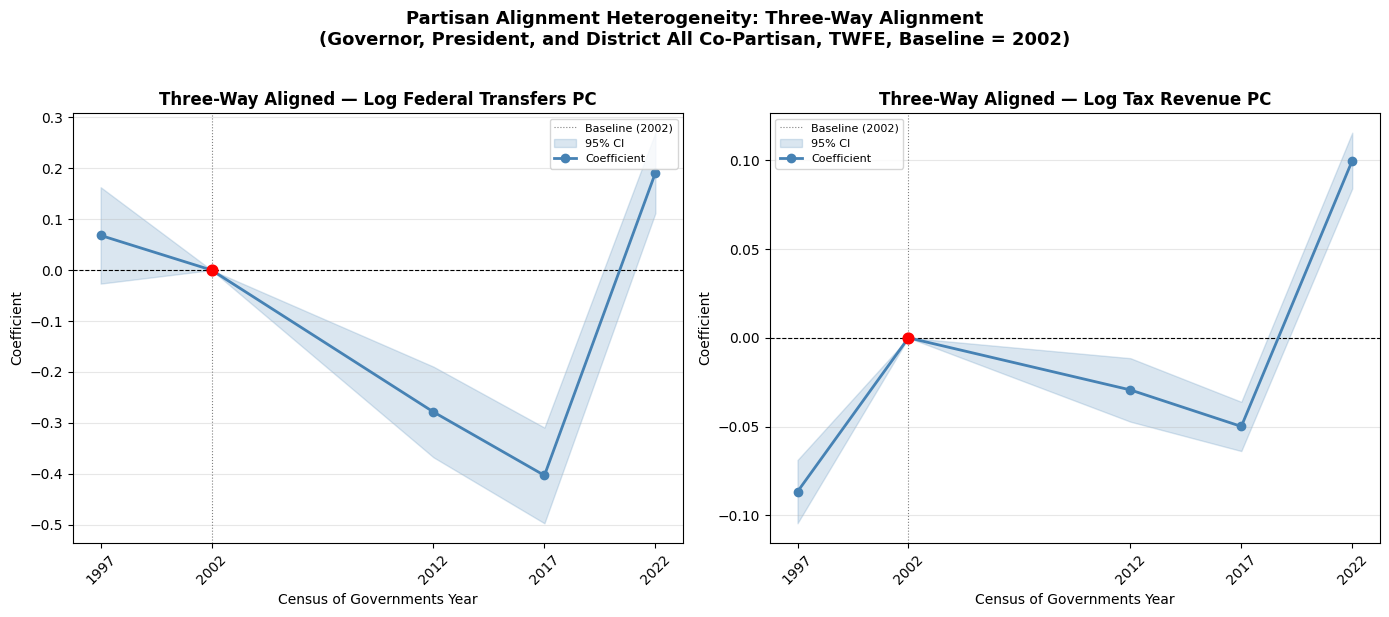

In [102]:
# ── Filter to 1997-2022 for alignment figure (Cook PVI available from 1997) ──
reg_df_align_pvi = reg_df_align[reg_df_align["year"] >= 1997].copy()

# Figure: Three-Way Aligned event study
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, interact_var, title in zip(
    axes,
    ["treat_x_three_way", "treat_x_three_way"],
    ["Three-Way Aligned — Log Federal Transfers PC",
     "Three-Way Aligned — Log Tax Revenue PC"]
):
    outcome = "log_transfers_pc" if "Transfers" in title else "log_tax_pc"
    coef_df, _ = run_event_study(reg_df_align_pvi, outcome, interact_var, 2002)
    plot_event_study(coef_df, title, ax, 2002)

fig.suptitle(
    "Partisan Alignment Heterogeneity: Three-Way Alignment\n"
    "(Governor, President, and District All Co-Partisan, TWFE, Baseline = 2002)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("figure4_three_way_alignment.png", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
from scipy.stats import norm as scipy_norm

print("\n" + "="*110)
print("PARTISAN ALIGNMENT HETEROGENEITY — KEY POST-BASELINE COEFFICIENTS (2017 and 2022)")
print("="*110)
print(f"{'Interaction':<25}  {'Outcome':<20}  {'Year':>6}  {'Coef':>10}  {'SE':>8}  {'p':>8}  {'Sig':>5}")
print("-"*110)

for interact_var, label in [
    ("treat",              "District Share (Main)"),
    ("treat_x_gov_pres",   "Gov-Pres Aligned"),
    ("treat_x_pres_pvi",   "Pres-PVI Aligned"),
    ("treat_x_three_way",  "Three-Way Aligned"),
    ("treat_x_pvi",        "District Share x PVI"),
]:
    for outcome, outcome_label in [
        ("log_transfers_pc", "Federal Transfers"),
        ("log_tax_pc",       "Tax Revenue"),
    ]:
        coef_df, _ = run_event_study(reg_df_align, outcome, interact_var, baseline_yr)
        for _, row in coef_df.iterrows():
            yr = int(row["year"])
            if yr not in [2017, 2022]:
                continue
            se   = row["se"]
            coef = row["coef"]
            p    = 2 * (1 - scipy_norm.cdf(abs(coef / se))) if se > 0 else np.nan
            sig  = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
            print(f"{label:<25}  {outcome_label:<20}  {yr:>6}  {coef:>10.4f}  {se:>8.4f}  {p:>8.4f}  {sig:>5}")
    print("-"*110)

print("="*110)


PARTISAN ALIGNMENT HETEROGENEITY — KEY POST-BASELINE COEFFICIENTS (2017 and 2022)
Interaction                Outcome                 Year        Coef        SE         p    Sig
--------------------------------------------------------------------------------------------------------------
District Share (Main)      Federal Transfers       2017     -0.3336    0.0270    0.0000    ***
District Share (Main)      Federal Transfers       2022      0.6182    0.0259    0.0000    ***
District Share (Main)      Tax Revenue             2017      0.1510    0.0203    0.0000    ***
District Share (Main)      Tax Revenue             2022      0.1985    0.0204    0.0000    ***
--------------------------------------------------------------------------------------------------------------
Gov-Pres Aligned           Federal Transfers       2017     -0.3110    0.0335    0.0000    ***
Gov-Pres Aligned           Federal Transfers       2022      0.4529    0.0368    0.0000    ***
Gov-Pres Aligned           Tax

In [27]:
waves = []
for year, path in WAVE_PATHS.items():
    df = pd.read_csv(path, dtype={"PLACE_ID": str})
    df.columns = df.columns.str.lower()
    df = df.rename(columns={
        "place_id": "PLACE_ID",
        "pop": "population"
    })
    df["year"] = year
    waves.append(df)
    print(f"{year}: {len(df):,} rows, {df['PLACE_ID'].nunique():,} unique places")

panel = pd.concat(waves, ignore_index=True)

1987: 21,554 rows, 21,554 unique places
1992: 35,771 rows, 23,883 unique places
1997: 35,097 rows, 32,796 unique places
2002: 29,283 rows, 27,629 unique places
2012: 35,220 rows, 32,895 unique places
2017: 34,746 rows, 32,499 unique places
2022: 34,069 rows, 31,913 unique places


In [28]:
from scipy.stats import chi2_contingency

data = {
    1987: {"total_split": 931,  "split_matched": 701,  "total_unified": 29793, "unified_matched": 20853},
    1992: {"total_split": 1228, "split_matched": 1004, "total_unified": 29496, "unified_matched": 22879},
    1997: {"total_split": 1228, "split_matched": 1080, "total_unified": 29496, "unified_matched": 25798},
    2002: {"total_split": 1172, "split_matched": 919,  "total_unified": 29552, "unified_matched": 22211},
    2012: {"total_split": 997,  "split_matched": 890,  "total_unified": 29727, "unified_matched": 26272},
    2017: {"total_split": 997,  "split_matched": 883,  "total_unified": 29727, "unified_matched": 26043},
    2022: {"total_split": 896,  "split_matched": 811,  "total_unified": 29828, "unified_matched": 25737},
}

print(f"{'Wave':<6}  {'Split Rate':>10}  {'Unified Rate':>12}  {'Chi2':>8}  {'p-value':>10}  {'Sig':>5}")
print("-"*60)

for yr, d in data.items():
    split_unmatched   = d["total_split"]   - d["split_matched"]
    unified_unmatched = d["total_unified"] - d["unified_matched"]
    
    contingency = [
        [d["split_matched"],   split_unmatched],
        [d["unified_matched"], unified_unmatched],
    ]
    
    chi2, p, dof, _ = chi2_contingency(contingency)
    sig = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    
    split_rate   = d["split_matched"]   / d["total_split"]
    unified_rate = d["unified_matched"] / d["total_unified"]
    
    print(f"{yr:<6}  {split_rate:>10.1%}  {unified_rate:>12.1%}  {chi2:>8.3f}  {p:>10.4f}  {sig:>5}")

Wave    Split Rate  Unified Rate      Chi2     p-value    Sig
------------------------------------------------------------
1987         75.3%         70.0%    11.871      0.0006    ***
1992         81.8%         77.6%    11.731      0.0006    ***
1997         87.9%         87.5%     0.211      0.6459       
2002         78.4%         75.2%     6.241      0.0125     **
2012         89.3%         88.4%     0.662      0.4160       
2017         88.6%         87.6%     0.732      0.3923       
2022         90.5%         86.3%    12.887      0.0003    ***


In [32]:
switchers = reg_df.groupby("PLACE_ID")["is_split"].nunique()
switcher_ids = switchers[switchers > 1].index

switcher_df = reg_df[reg_df["PLACE_ID"].isin(switcher_ids)].copy()

first_split = (
    switcher_df[switcher_df["is_split"] == 1]
    .groupby("PLACE_ID")["year"]
    .min()
    .rename("first_split_year")
)

print(first_split.value_counts().sort_index())

first_split_year
1987    594
1992    667
1997     80
2002    456
2012    323
2022    255
Name: count, dtype: int64


In [ ]:
# ============================================================
# RELATIVE TIME EVENT STUDY WITH NEVER-SPLIT CONTROLS
# ============================================================

# Step 1: identify switchers and their first treatment wave
switchers = reg_df.groupby("PLACE_ID")["is_split"].nunique()
switcher_ids = switchers[switchers > 1].index

switcher_df = reg_df[reg_df["PLACE_ID"].isin(switcher_ids)].copy()

first_split = (
    switcher_df[switcher_df["is_split"] == 1]
    .groupby("PLACE_ID")["year"]
    .min()
    .rename("first_split_year")
)

switcher_df = switcher_df.merge(first_split, on="PLACE_ID", how="left")

# Step 2: map calendar year to relative time using wave index
wave_order = {1987: 0, 1992: 1, 1997: 2, 2002: 3, 2012: 4, 2017: 5, 2022: 6}
switcher_df["wave_idx"]        = switcher_df["year"].map(wave_order)
switcher_df["first_split_idx"] = switcher_df["first_split_year"].map(wave_order)
switcher_df["rel_time"]        = switcher_df["wave_idx"] - switcher_df["first_split_idx"]

# Step 3: keep only clean window around treatment
switcher_df = switcher_df[switcher_df["rel_time"].between(-3, 3)].copy()

# Step 4: add never-split controls with rel_time = NaN
never_split_ids = reg_df.groupby("PLACE_ID")["is_split"].max()
never_split_ids = never_split_ids[never_split_ids == 0].index

rel_df = pd.concat([
    switcher_df,
    reg_df[reg_df["PLACE_ID"].isin(never_split_ids)].assign(rel_time=np.nan)
], ignore_index=True)

print(f"Switchers: {len(switcher_ids):,}")
print(f"Never-split controls: {len(never_split_ids):,}")
print(f"Total observations: {len(rel_df):,}")

# Step 5: create relative time dummies
def rel_label(r):
    return f"m{abs(int(r))}" if r < 0 else f"p{int(r)}"

rel_baseline = -1
rel_baseline_label = rel_label(rel_baseline)
rel_years = [r for r in sorted(switcher_df["rel_time"].unique()) if r != rel_baseline]
rel_labels = [rel_label(r) for r in rel_years]

for r, lbl in zip(rel_years, rel_labels):
    rel_df[f"tx_rel{lbl}"] = ((rel_df["rel_time"] == r) & rel_df["rel_time"].notna()).astype(float)

# Step 6: demean within PLACE_ID and year
def within_demean(df, col, group):
    return df[col] - df.groupby(group)[col].transform("mean")

cols = [f"tx_rel{lbl}" for lbl in rel_labels]
for col in cols:
    rel_df[f"dm_{col}"] = within_demean(rel_df, col, "PLACE_ID")
for col in cols:
    rel_df[f"dm_{col}"] = within_demean(rel_df, f"dm_{col}", "year")

for outcome in ["log_transfers_pc", "log_tax_pc"]:
    rel_df[f"dm_{outcome}"] = within_demean(rel_df, outcome, "PLACE_ID")
    rel_df[f"dm_{outcome}"] = within_demean(rel_df, f"dm_{outcome}", "year")

# Step 6b: demean demographic controls
DEMO_CONTROL_COLS = [
    "pct_white", "pct_black", "pct_aian", "pct_asian", "pct_hispanic",
    "pct_urban", "pct_rural", "pct_owner_occupied",
    "pct_college", "log_median_income_1990",
]

demo_cols_present = [c for c in DEMO_CONTROL_COLS if c in rel_df.columns and rel_df[c].notna().any()]

for col in demo_cols_present:
    rel_df[f"dm_{col}"] = within_demean(rel_df, col, "PLACE_ID")
for col in demo_cols_present:
    rel_df[f"dm_{col}"] = within_demean(rel_df, f"dm_{col}", "year")

tx_terms   = " + ".join([f"dm_tx_rel{lbl}" for lbl in rel_labels])
demo_terms = " + ".join([f"dm_{c}" for c in demo_cols_present])

# Step 7: plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, outcome, title in zip(
    axes,
    ["log_transfers_pc", "log_tax_pc"],
    ["Log Federal Transfers PC", "Log Tax Revenue PC"]
):
    # Drop rows missing outcome OR any demographic control
    drop_cols = [outcome] + [f"dm_{c}" for c in demo_cols_present]
    d = rel_df.dropna(subset=drop_cols).copy()

    formula = f"dm_{outcome} ~ {tx_terms} + {demo_terms} - 1"
    model = smf.ols(formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["PLACE_ID"]}
    )

    coef_df = pd.DataFrame({
        "rel_time": rel_years,
        "coef": [model.params.get(f"dm_tx_rel{lbl}", np.nan) for lbl in rel_labels],
        "se":   [model.bse.get(f"dm_tx_rel{lbl}", np.nan) for lbl in rel_labels],
    })
    coef_df = pd.concat([
        coef_df,
        pd.DataFrame({"rel_time": [rel_baseline], "coef": [0.0], "se": [0.0]})
    ]).sort_values("rel_time").reset_index(drop=True)
    coef_df["ci_lo"] = coef_df["coef"] - 1.96 * coef_df["se"]
    coef_df["ci_hi"] = coef_df["coef"] + 1.96 * coef_df["se"]

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(rel_baseline, color="gray", linewidth=0.8, linestyle=":", label="Baseline (t=-1)")
    ax.fill_between(coef_df["rel_time"], coef_df["ci_lo"], coef_df["ci_hi"],
                    alpha=0.2, color="steelblue", label="95% CI")
    ax.plot(coef_df["rel_time"], coef_df["coef"],
            color="steelblue", marker="o", linewidth=2, markersize=6, label="Coefficient")
    ax.scatter([rel_baseline], [0], color="red", zorder=5, s=60)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Waves Relative to First Split", fontsize=10)
    ax.set_ylabel("Coefficient", fontsize=10)
    ax.xaxis.set_major_locator(mticker.FixedLocator(sorted(coef_df["rel_time"].tolist())))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle(
    "Relative Time Event Study: Effect of First Becoming Split\n"
    "on Municipal Finance (Switchers vs Never-Split Controls, Baseline = t-1)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("figure5_relative_time.png", dpi=300, bbox_inches='tight')
plt.show()

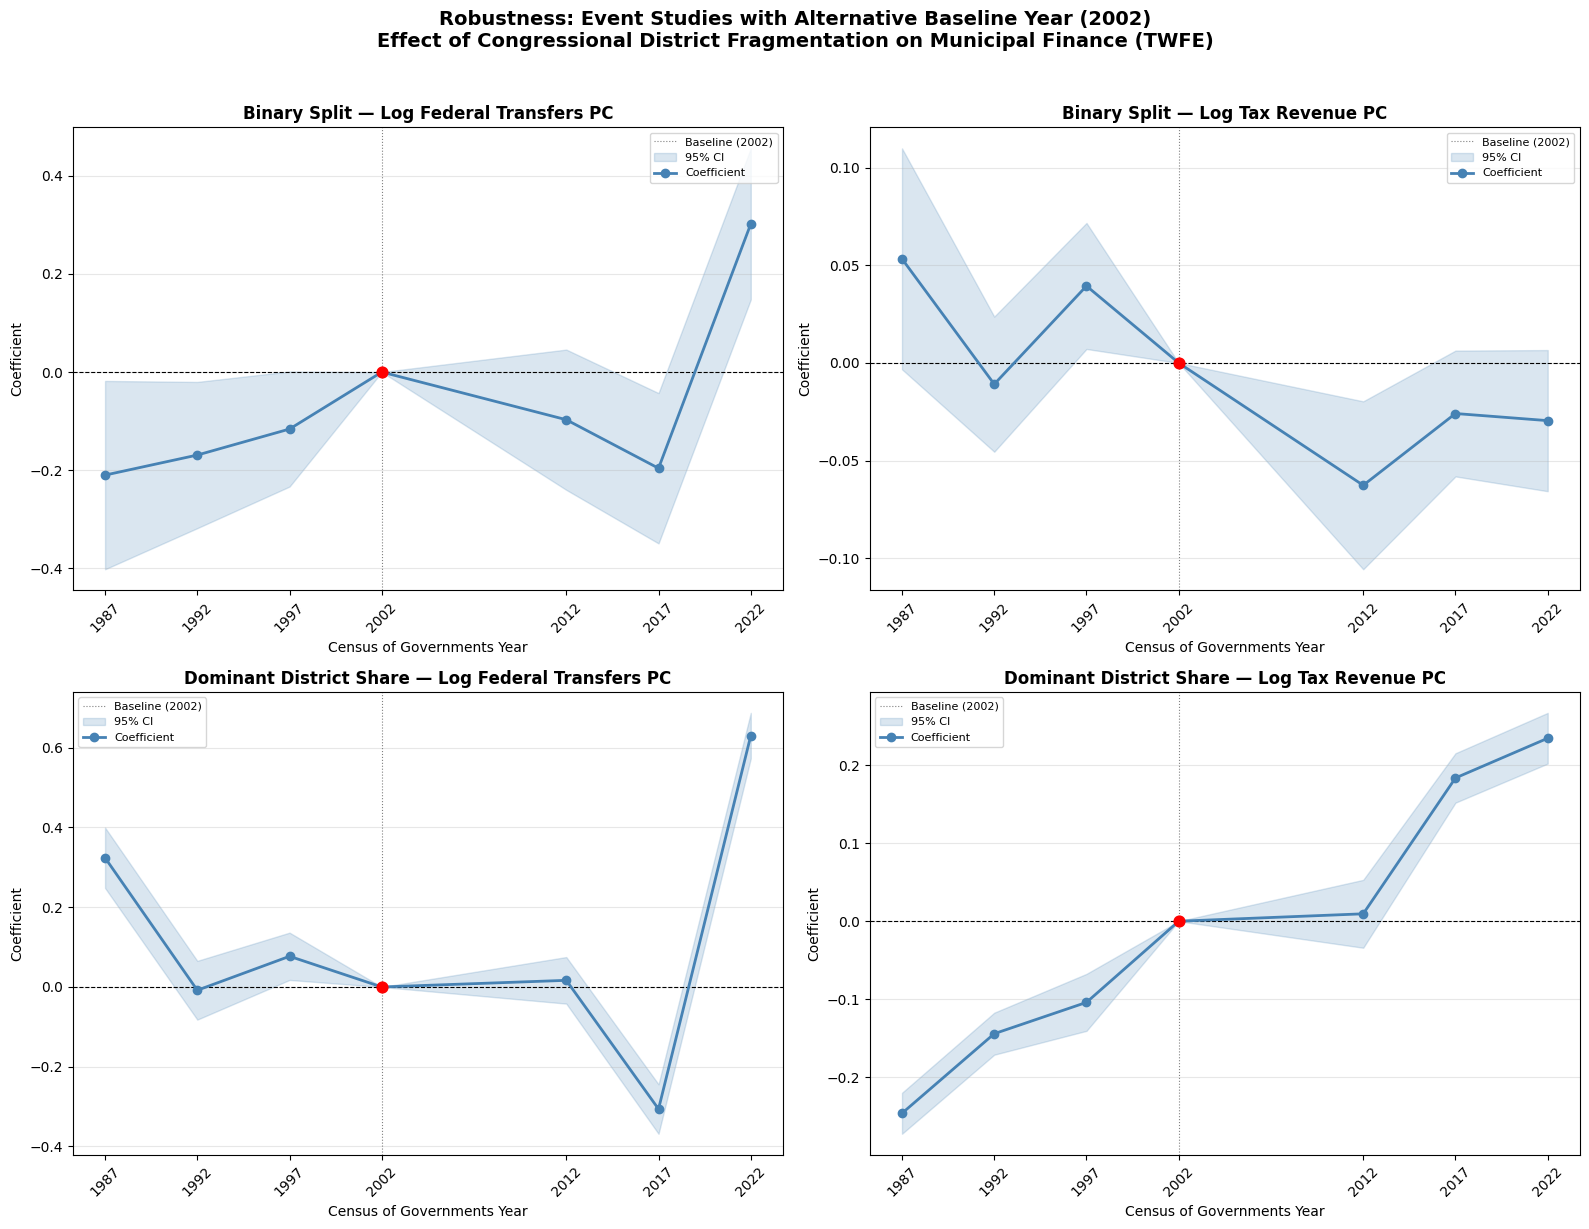


EVENT STUDY: Binary Split — Log Federal Transfers PC
Baseline: 2002
---------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi
---------------------------------------------------------------------------
  1987     -0.2098      0.0978     -2.14    0.0320     -0.4016     -0.0181  **
  1992     -0.1690      0.0760     -2.22    0.0261     -0.3179     -0.0201  **
  1997     -0.1160      0.0598     -1.94    0.0523     -0.2332      0.0011  *
  2002      0.0000      0.0000       nan       nan      0.0000      0.0000   <- baseline
  2012     -0.0971      0.0729     -1.33    0.1828     -0.2399      0.0457  
  2017     -0.1959      0.0781     -2.51    0.0121     -0.3489     -0.0428  **
  2022      0.3016      0.0785      3.84    0.0001      0.1477      0.4554  ***

EVENT STUDY: Binary Split — Log Tax Revenue PC
Baseline: 2002
---------------------------------------------------------------------------
  Ye

In [39]:
alt_baseline_yr = 2002

coef_alt_binary_transfers, _ = run_event_study(reg_df, "log_transfers_pc", "treatment_binary", alt_baseline_yr)
coef_alt_binary_tax,       _ = run_event_study(reg_df, "log_tax_pc",       "treatment_binary", alt_baseline_yr)
coef_alt_cont_transfers,   _ = run_event_study(reg_df, "log_transfers_pc", "treatment_cont",   alt_baseline_yr)
coef_alt_cont_tax,         _ = run_event_study(reg_df, "log_tax_pc",       "treatment_cont",   alt_baseline_yr)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_event_study(coef_alt_binary_transfers, "Binary Split — Log Federal Transfers PC",            axes[0,0], alt_baseline_yr)
plot_event_study(coef_alt_binary_tax,       "Binary Split — Log Tax Revenue PC",                  axes[0,1], alt_baseline_yr)
plot_event_study(coef_alt_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", axes[1,0], alt_baseline_yr)
plot_event_study(coef_alt_cont_tax,         "Dominant District Share — Log Tax Revenue PC",       axes[1,1], alt_baseline_yr)

fig.suptitle(
    "Robustness: Event Studies with Alternative Baseline Year (2002)\n"
    "Effect of Congressional District Fragmentation on Municipal Finance (TWFE)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

print_coef_table(coef_alt_binary_transfers, "Binary Split — Log Federal Transfers PC",            alt_baseline_yr)
print_coef_table(coef_alt_binary_tax,       "Binary Split — Log Tax Revenue PC",                  alt_baseline_yr)
print_coef_table(coef_alt_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", alt_baseline_yr)
print_coef_table(coef_alt_cont_tax,         "Dominant District Share — Log Tax Revenue PC",       alt_baseline_yr)


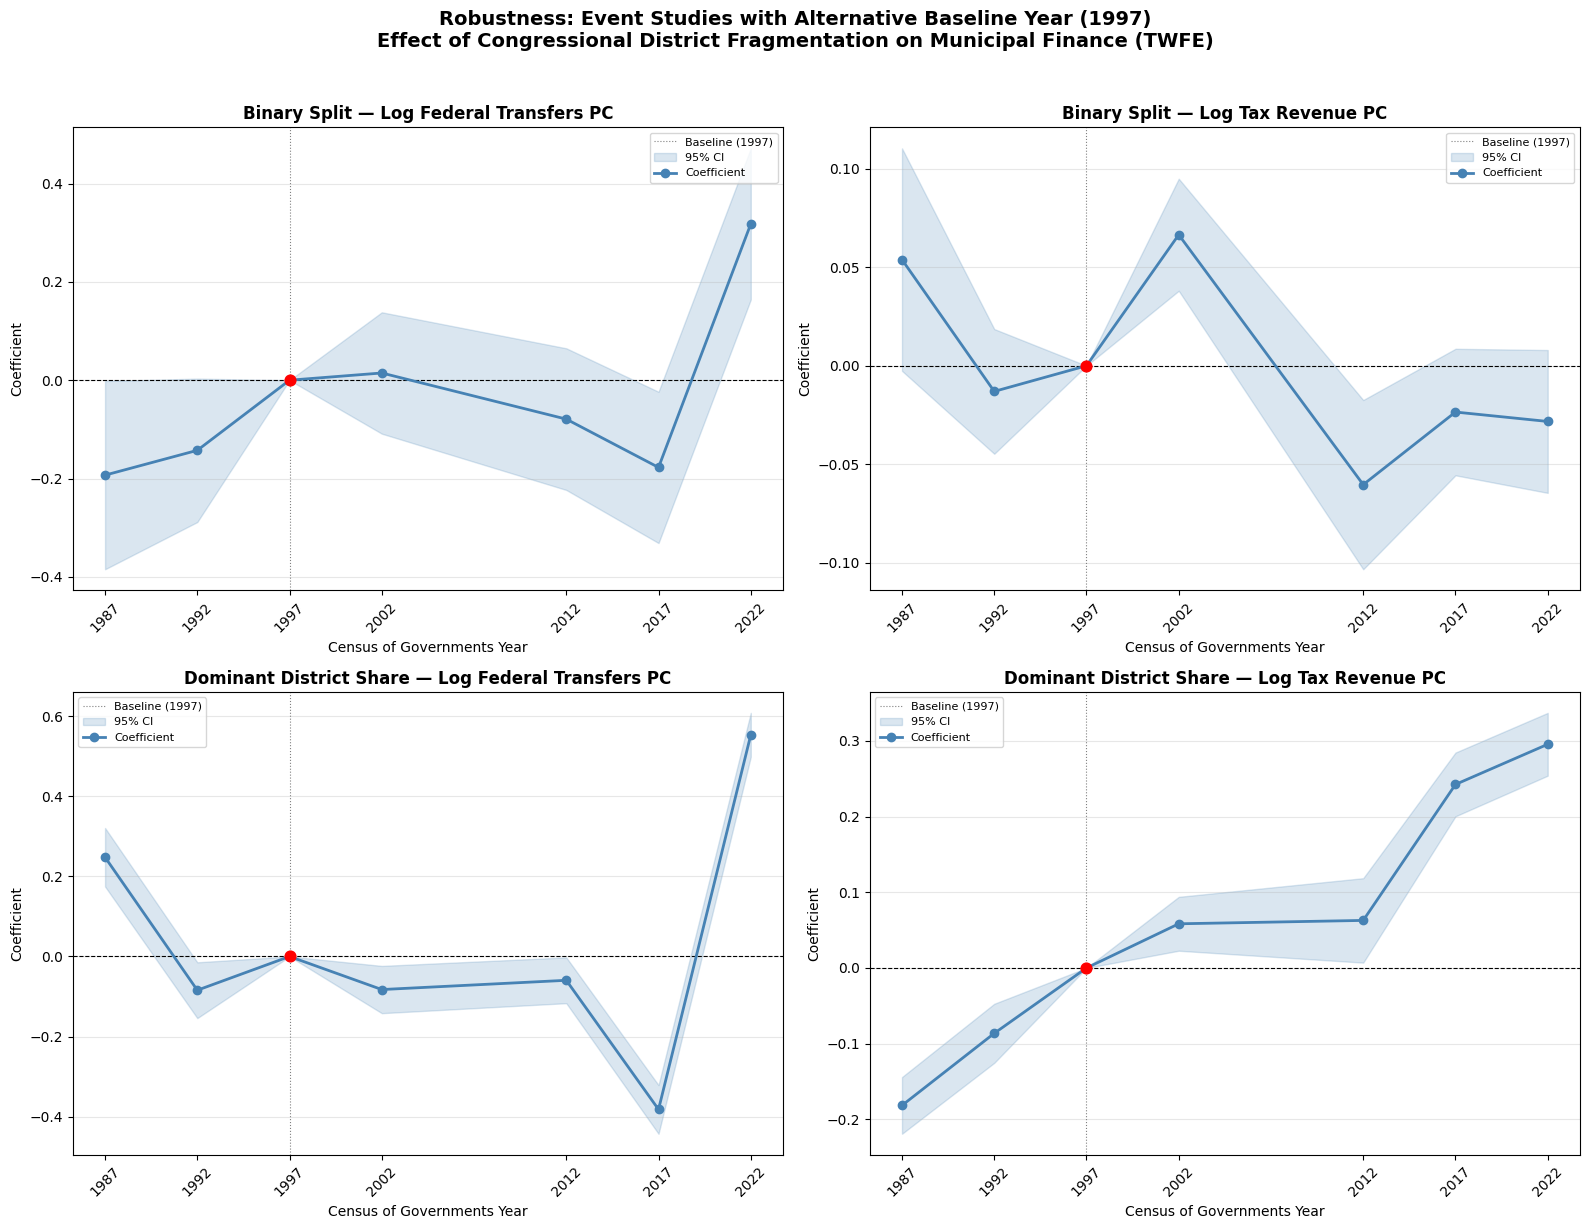


EVENT STUDY: Binary Split — Log Federal Transfers PC
Baseline: 1997
---------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi
---------------------------------------------------------------------------
  1987     -0.1931      0.0977     -1.98    0.0481     -0.3845     -0.0016  **
  1992     -0.1426      0.0744     -1.92    0.0552     -0.2885      0.0032  *
  1997      0.0000      0.0000       nan       nan      0.0000      0.0000   <- baseline
  2002      0.0147      0.0630      0.23    0.8157     -0.1087      0.1381  
  2012     -0.0791      0.0735     -1.08    0.2815     -0.2232      0.0649  
  2017     -0.1774      0.0785     -2.26    0.0238     -0.3312     -0.0235  **
  2022      0.3178      0.0784      4.05    0.0001      0.1641      0.4715  ***

EVENT STUDY: Binary Split — Log Tax Revenue PC
Baseline: 1997
---------------------------------------------------------------------------
  Year

In [40]:
# ============================================================
# ROBUSTNESS: ALTERNATIVE BASELINE YEAR (1997)
# ============================================================

alt_baseline_yr2 = 1997

coef_alt2_binary_transfers, _ = run_event_study(reg_df, "log_transfers_pc", "treatment_binary", alt_baseline_yr2)
coef_alt2_binary_tax,       _ = run_event_study(reg_df, "log_tax_pc",       "treatment_binary", alt_baseline_yr2)
coef_alt2_cont_transfers,   _ = run_event_study(reg_df, "log_transfers_pc", "treatment_cont",   alt_baseline_yr2)
coef_alt2_cont_tax,         _ = run_event_study(reg_df, "log_tax_pc",       "treatment_cont",   alt_baseline_yr2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_event_study(coef_alt2_binary_transfers, "Binary Split — Log Federal Transfers PC",            axes[0,0], alt_baseline_yr2)
plot_event_study(coef_alt2_binary_tax,       "Binary Split — Log Tax Revenue PC",                  axes[0,1], alt_baseline_yr2)
plot_event_study(coef_alt2_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", axes[1,0], alt_baseline_yr2)
plot_event_study(coef_alt2_cont_tax,         "Dominant District Share — Log Tax Revenue PC",       axes[1,1], alt_baseline_yr2)

fig.suptitle(
    "Robustness: Event Studies with Alternative Baseline Year (1997)\n"
    "Effect of Congressional District Fragmentation on Municipal Finance (TWFE)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

print_coef_table(coef_alt2_binary_transfers, "Binary Split — Log Federal Transfers PC",            alt_baseline_yr2)
print_coef_table(coef_alt2_binary_tax,       "Binary Split — Log Tax Revenue PC",                  alt_baseline_yr2)
print_coef_table(coef_alt2_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", alt_baseline_yr2)
print_coef_table(coef_alt2_cont_tax,         "Dominant District Share — Log Tax Revenue PC",       alt_baseline_yr2)

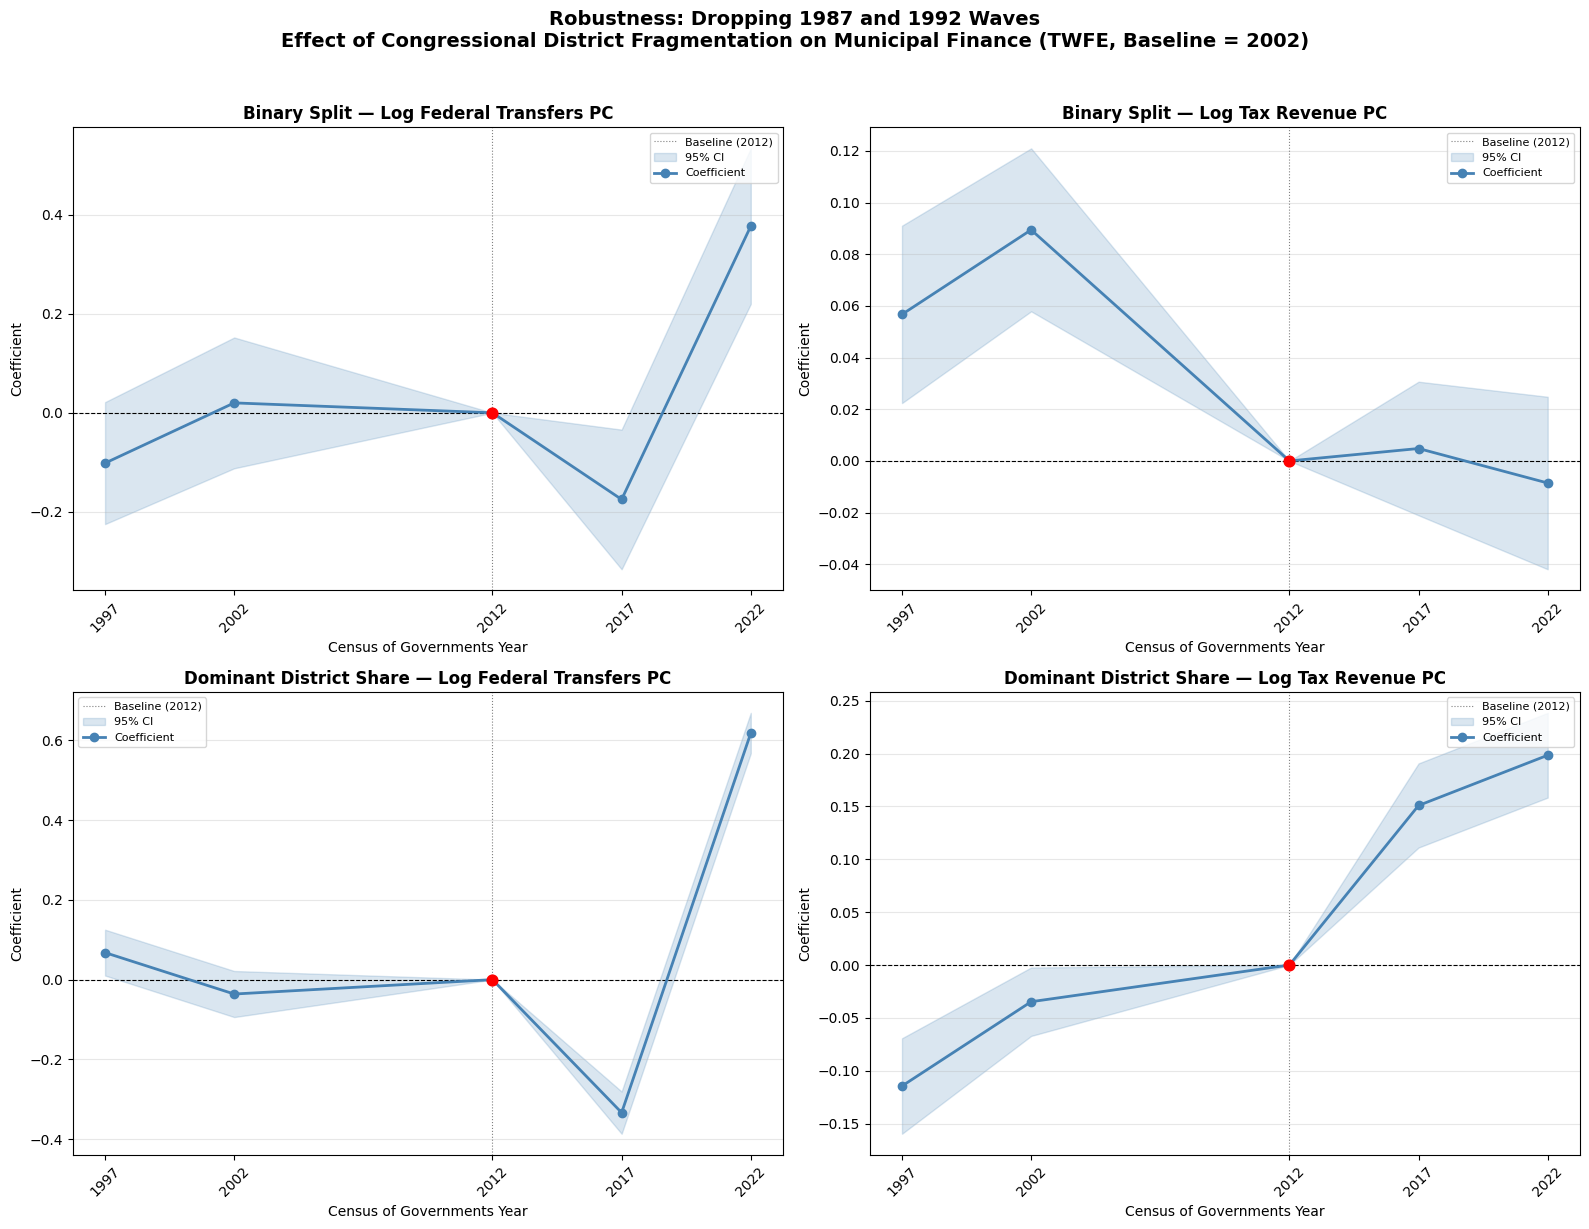


EVENT STUDY: Binary Split — Log Federal Transfers PC
Baseline: 2012
---------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi
---------------------------------------------------------------------------
  1997     -0.1015      0.0628     -1.62    0.1058     -0.2245      0.0215  
  2002      0.0200      0.0673      0.30    0.7665     -0.1120      0.1520  
  2012      0.0000      0.0000       nan       nan      0.0000      0.0000   <- baseline
  2017     -0.1748      0.0719     -2.43    0.0150     -0.3157     -0.0339  **
  2022      0.3766      0.0801      4.70    0.0000      0.2197      0.5335  ***

EVENT STUDY: Binary Split — Log Tax Revenue PC
Baseline: 2012
---------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi
---------------------------------------------------------------------------
  1997      

In [ ]:
# ============================================================
# ROBUSTNESS: DROP 1987 AND 1992 WAVES
# ============================================================

reg_df_clean = reg_df[reg_df["year"].isin([1997, 2002, 2012, 2017, 2022])].copy()

coef_clean_binary_transfers, _ = run_event_study(reg_df_clean, "log_transfers_pc", "treatment_binary", baseline_yr)
coef_clean_binary_tax,       _ = run_event_study(reg_df_clean, "log_tax_pc",       "treatment_binary", baseline_yr)
coef_clean_cont_transfers,   _ = run_event_study(reg_df_clean, "log_transfers_pc", "treatment_cont",   baseline_yr)
coef_clean_cont_tax,         _ = run_event_study(reg_df_clean, "log_tax_pc",       "treatment_cont",   baseline_yr)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_event_study(coef_clean_binary_transfers, "Binary Split — Log Federal Transfers PC",            axes[0,0], baseline_yr)
plot_event_study(coef_clean_binary_tax,       "Binary Split — Log Tax Revenue PC",                  axes[0,1], baseline_yr)
plot_event_study(coef_clean_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", axes[1,0], baseline_yr)
plot_event_study(coef_clean_cont_tax,         "Dominant District Share — Log Tax Revenue PC",       axes[1,1], baseline_yr)

fig.suptitle(
    "Robustness: Dropping 1987 and 1992 Waves\n"
    "Effect of Congressional District Fragmentation on Municipal Finance (TWFE, Baseline = 2002)",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

print_coef_table(coef_clean_binary_transfers, "Binary Split — Log Federal Transfers PC",            baseline_yr)
print_coef_table(coef_clean_binary_tax,       "Binary Split — Log Tax Revenue PC",                  baseline_yr)
print_coef_table(coef_clean_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", baseline_yr)
print_coef_table(coef_clean_cont_tax,         "Dominant District Share — Log Tax Revenue PC",       baseline_yr)

In [58]:
import pandas as pd
import numpy as np
from scipy import stats

# ============================================================
# LOAD PANEL
# ============================================================

WAVE_PATHS = {
    1987: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/1987_Individual Unit_file/cog1987_muni_real_percap.csv",
    1992: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/1992_Individual_Unit_File/cog1992_muni_real_percap.csv",
    1997: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/1997_Individual_Unit_file/cog1997_muni_real_percap.csv",
    2002: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/2002_Individual Unit_file/cog2002_muni_real_percap.csv",
    2012: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/2012_Individual_Unit_file (1)/cog2012_muni_real_percap.csv",
    2017: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/2017_Individual_Unit_File (1)/cog2017_muni_real_percap.csv",
    2022: "/Users/mayarabin/Desktop/Thesis Downloads V2/Small Town:City Economic Data/2022_Individual_Unit_File/cog2022_muni_real_percap.csv",
}

waves = []
for year, path in WAVE_PATHS.items():
    df = pd.read_csv(path, dtype={"PLACE_ID": str})
    df["year"] = year
    waves.append(df)

panel = pd.concat(waves, ignore_index=True)

for col in ["federal_transfers_pc", "dist1_share"]:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

panel["log_transfers_pc"] = np.log(panel["federal_transfers_pc"].replace(0, np.nan))
panel["PLACE_ID"] = panel["PLACE_ID"].astype(str)
panel["year"] = panel["year"].astype(int)

# ============================================================
# TWO-WAY FIXED EFFECTS EVENT STUDY
# Baseline: 2002, Treatment: dist1_share (continuous)
# Outcome: log_transfers_pc
# Clustered SEs at PLACE_ID level
# ============================================================

BASELINE = 2002

reg = panel.dropna(subset=["log_transfers_pc", "dist1_share", "PLACE_ID", "year"]).copy()

# Within-demean on PLACE_ID and year (two-way FE)
reg["y_dm"] = (
    reg["log_transfers_pc"]
    - reg.groupby("PLACE_ID")["log_transfers_pc"].transform("mean")
    - reg.groupby("year")["log_transfers_pc"].transform("mean")
    + reg["log_transfers_pc"].mean()
)

event_years = [y for y in sorted(reg["year"].unique()) if y != BASELINE]

# Interaction terms: dist1_share * year_dummy
for yr in event_years:
    reg[f"tx{yr}"] = reg["dist1_share"] * (reg["year"] == yr).astype(float)

tx_cols = [f"tx{yr}" for yr in event_years]

# Demean all regressors
for col in ["dist1_share"] + tx_cols:
    reg[f"{col}_dm"] = (
        reg[col]
        - reg.groupby("PLACE_ID")[col].transform("mean")
        - reg.groupby("year")[col].transform("mean")
        + reg[col].mean()
    )

X_cols = [f"{c}_dm" for c in tx_cols]
X = reg[X_cols].values
y = reg["y_dm"].values

# OLS
XtX_inv = np.linalg.pinv(X.T @ X)
betas = XtX_inv @ X.T @ y
resids = y - X @ betas

# Clustered SEs at PLACE_ID level
clusters = reg["PLACE_ID"].values
unique_clusters = np.unique(clusters)
G = len(unique_clusters)
N = len(y)
K = X.shape[1]

meat = np.zeros((K, K))
for g in unique_clusters:
    mask = clusters == g
    Xg = X[mask]
    eg = resids[mask]
    meat += Xg.T @ (eg[:, None] * eg[None, :]) @ np.ones((len(eg), len(eg))) @ Xg
    # simpler: score outer product
    score_g = Xg.T @ eg
    meat += np.outer(score_g, score_g)

# Small-sample correction
correction = (G / (G - 1)) * ((N - 1) / (N - K))
vcov = correction * XtX_inv @ meat @ XtX_inv
ses = np.sqrt(np.diag(vcov))

# ============================================================
# PRINT RESULTS
# ============================================================

print(f"\nEvent Study: log(Federal Transfers PC) ~ dist1_share x year dummies")
print(f"Baseline year: {BASELINE}")
print(f"N observations: {len(reg):,}  |  N places: {reg['PLACE_ID'].nunique():,}")
print(f"\n{'Year':<8} {'Coef':>10} {'SE':>10} {'t':>8} {'p-value':>10} {'Pct Effect (0.5->1.0)':>22}")
print("-" * 72)

for i, yr in enumerate(event_years):
    b = betas[i]
    se = ses[i]
    t_stat = b / se
    p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=G - 1))
    # Implied % effect of moving dist1_share from 0.5 to 1.0 (split -> unified)
    pct_effect = (np.exp(b * 0.5) - 1) * 100
    stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{yr:<8} {b:>10.3f} {se:>10.3f} {t_stat:>8.3f} {p_val:>10.4f} {pct_effect:>18.1f}%  {stars}")

print("-" * 72)
print("Note: Pct Effect = implied % change moving dist1_share from 0.5 to 1.0")
print("      (two-way split to full unification). Stars: * p<.05, ** p<.01, *** p<.001")


Event Study: log(Federal Transfers PC) ~ dist1_share x year dummies
Baseline year: 2002
N observations: 47,073  |  N places: 19,587

Year           Coef         SE        t    p-value  Pct Effect (0.5->1.0)
------------------------------------------------------------------------
1992          0.162      0.013   12.580     0.0000                8.5%  ***
1997          0.179      0.010   17.650     0.0000                9.4%  ***
2012          0.059      0.010    5.706     0.0000                3.0%  ***
2017         -0.271      0.011  -24.894     0.0000              -12.7%  ***
2022          0.654      0.008   77.346     0.0000               38.7%  ***
------------------------------------------------------------------------
Note: Pct Effect = implied % change moving dist1_share from 0.5 to 1.0
      (two-way split to full unification). Stars: * p<.05, ** p<.01, *** p<.001


In [59]:
# ============================================================
# CLEAN RERUN: All-years coefficients, dist1_share -> log_transfers_pc
# Baseline: 2002 | TWFE | Clustered SEs at PLACE_ID level
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import norm as scipy_norm

def within_demean(df, col, group):
    return df[col] - df.groupby(group)[col].transform("mean")

def run_event_study_clean(df, outcome_col, treatment_col, baseline_yr):
    d = df.dropna(subset=[outcome_col, treatment_col, "PLACE_ID", "year"]).copy()
    d[treatment_col] = pd.to_numeric(d[treatment_col], errors="coerce")
    d = d.dropna(subset=[treatment_col])

    yrs = [y for y in sorted(d["year"].unique()) if y != baseline_yr]

    for yr in yrs:
        d[f"tx{yr}"] = d[treatment_col] * (d["year"] == yr).astype(float)

    cols = [outcome_col, treatment_col] + [f"tx{yr}" for yr in yrs]
    for col in cols:
        d[f"dm_{col}"] = within_demean(d, col, "PLACE_ID")
    for col in cols:
        d[f"dm_{col}"] = within_demean(d, f"dm_{col}", "year")

    terms   = " + ".join([f"dm_tx{yr}" for yr in yrs])
    formula = f"dm_{outcome_col} ~ {terms} - 1"

    model = smf.ols(formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d["PLACE_ID"]}
    )

    rows = []
    for yr in yrs:
        coef = model.params.get(f"dm_tx{yr}", np.nan)
        se   = model.bse.get(f"dm_tx{yr}", np.nan)
        rows.append({"year": yr, "coef": coef, "se": se})
    rows.append({"year": baseline_yr, "coef": 0.0, "se": 0.0})

    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)

# Run it
coef_df = run_event_study_clean(reg_df, "log_transfers_pc", "treatment_cont", 2002)

# Print table
print("\nEvent Study: log(Federal Transfers PC) ~ dist1_share x year dummies")
print("Baseline: 2002 | TWFE | Clustered SEs at PLACE_ID level")
print(f"{'Year':<8} {'Coef':>10} {'SE':>10} {'p-value':>10} {'Pct Effect (0.5->1.0)':>22}")
print("-" * 68)

for _, row in coef_df.iterrows():
    yr   = int(row["year"])
    coef = row["coef"]
    se   = row["se"]
    p    = 2 * (1 - scipy_norm.cdf(abs(coef / se))) if se > 0 else float("nan")
    pct  = (np.exp(coef * 0.5) - 1) * 100
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    base  = " <- baseline" if yr == 2002 else ""
    print(f"{yr:<8} {coef:>10.3f} {se:>10.3f} {p:>10.4f} {pct:>18.1f}%  {stars}{base}")

print("-" * 68)
print("Pct Effect = implied % change moving dist1_share from 0.5 to 1.0")
print("            (two-way split to full unification)")


Event Study: log(Federal Transfers PC) ~ dist1_share x year dummies
Baseline: 2002 | TWFE | Clustered SEs at PLACE_ID level
Year           Coef         SE    p-value  Pct Effect (0.5->1.0)
--------------------------------------------------------------------
1987          0.324      0.039     0.0000               17.6%  ***
1992         -0.008      0.038     0.8272               -0.4%  
1997          0.077      0.030     0.0110                3.9%  *
2002          0.000      0.000        nan                0.0%   <- baseline
2012          0.017      0.030     0.5760                0.8%  
2017         -0.306      0.032     0.0000              -14.2%  ***
2022          0.630      0.029     0.0000               37.0%  ***
--------------------------------------------------------------------
Pct Effect = implied % change moving dist1_share from 0.5 to 1.0
            (two-way split to full unification)


In [60]:
# Run it
coef_df_binary = run_event_study_clean(reg_df, "log_transfers_pc", "treatment_binary", 2002)

# Print table
print("\nEvent Study: log(Federal Transfers PC) ~ is_split x year dummies")
print("Baseline: 2002 | TWFE | Clustered SEs at PLACE_ID level")
print(f"{'Year':<8} {'Coef':>10} {'SE':>10} {'p-value':>10} {'Pct Effect (split=1)':>22}")
print("-" * 68)

for _, row in coef_df_binary.iterrows():
    yr   = int(row["year"])
    coef = row["coef"]
    se   = row["se"]
    p    = 2 * (1 - scipy_norm.cdf(abs(coef / se))) if se > 0 else float("nan")
    pct  = (np.exp(coef) - 1) * 100
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    base  = " <- baseline" if yr == 2002 else ""
    print(f"{yr:<8} {coef:>10.3f} {se:>10.3f} {p:>10.4f} {pct:>18.1f}%  {stars}{base}")

print("-" * 68)
print("Pct Effect = implied % change from being split vs unified")


Event Study: log(Federal Transfers PC) ~ is_split x year dummies
Baseline: 2002 | TWFE | Clustered SEs at PLACE_ID level
Year           Coef         SE    p-value   Pct Effect (split=1)
--------------------------------------------------------------------
1987         -0.210      0.098     0.0320              -18.9%  *
1992         -0.169      0.076     0.0261              -15.5%  *
1997         -0.116      0.060     0.0523              -11.0%  
2002          0.000      0.000        nan                0.0%   <- baseline
2012         -0.097      0.073     0.1828               -9.3%  
2017         -0.196      0.078     0.0121              -17.8%  *
2022          0.302      0.078     0.0001               35.2%  ***
--------------------------------------------------------------------
Pct Effect = implied % change from being split vs unified


In [62]:
# ── Gov-PVI Aligned interaction (missing from Table 7) ────────────────────

reg_df_align["gov_pvi_aligned_new"] = (
    reg_df_align["gov_party_norm"] == reg_df_align["pvi_party_norm"]
).astype(float)

reg_df_align["treat_x_gov_pvi"] = (
    reg_df_align["treat"] * reg_df_align["gov_pvi_aligned_new"]
)

# Pull 2017 and 2022 coefficients for both outcomes
print(f"\n{'Outcome':<20}  {'Year':>6}  {'Coef':>10}  {'SE':>8}  {'p':>8}  {'Sig':>5}")
print("-" * 60)

for outcome, outcome_label in [
    ("log_transfers_pc", "Federal Transfers"),
    ("log_tax_pc",       "Tax Revenue"),
]:
    coef_df, _ = run_event_study(reg_df_align, outcome, "treat_x_gov_pvi", baseline_yr)
    for _, row in coef_df.iterrows():
        yr = int(row["year"])
        if yr not in [2017, 2022]:
            continue
        coef = row["coef"]
        se   = row["se"]
        p    = 2 * (1 - scipy_norm.cdf(abs(coef / se))) if se > 0 else np.nan
        sig  = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
        print(f"{outcome_label:<20}  {yr:>6}  {coef:>10.4f}  {se:>8.4f}  {p:>8.4f}  {sig:>5}")


Outcome                 Year        Coef        SE         p    Sig
------------------------------------------------------------
Federal Transfers       2017     -0.3421    0.0354    0.0000    ***
Federal Transfers       2022      0.2172    0.0334    0.0000    ***
Tax Revenue             2017      0.0300    0.0060    0.0000    ***
Tax Revenue             2022      0.0635    0.0069    0.0000    ***


In [63]:
# Alternative Baseline 2002 — exact coefficients for Section VI.C text
from scipy.stats import norm as scipy_norm

print("\n" + "="*80)
print("ALTERNATIVE BASELINE 2002 — KEY COEFFICIENTS FOR PAPER TEXT")
print("="*80)

for treatment, label in [
    ("treatment_cont",   "Dominant District Share"),
    ("treatment_binary", "Binary Split"),
]:
    for outcome, olabel in [
        ("log_transfers_pc", "Federal Transfers"),
        ("log_tax_pc",       "Tax Revenue"),
    ]:
        coef_df = run_event_study_clean(reg_df, outcome, treatment, 2002)
        print(f"\n{label} — {olabel}")
        print(f"{'Year':<8} {'Coef':>10} {'SE':>8} {'p':>8} {'Sig':>5}")
        print("-"*45)
        for _, row in coef_df.iterrows():
            yr   = int(row["year"])
            coef = row["coef"]
            se   = row["se"]
            p    = 2 * (1 - scipy_norm.cdf(abs(coef / se))) if se > 0 else float("nan")
            sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
            base = " <- baseline" if yr == 2002 else ""
            print(f"{yr:<8} {coef:>10.4f} {se:>8.4f} {p:>8.4f}  {sig}{base}")


ALTERNATIVE BASELINE 2002 — KEY COEFFICIENTS FOR PAPER TEXT

Dominant District Share — Federal Transfers
Year           Coef       SE        p   Sig
---------------------------------------------
1987         0.3239   0.0386   0.0000  ***
1992        -0.0082   0.0376   0.8272  
1997         0.0769   0.0303   0.0110  *
2002         0.0000   0.0000      nan   <- baseline
2012         0.0167   0.0298   0.5760  
2017        -0.3061   0.0316   0.0000  ***
2022         0.6303   0.0291   0.0000  ***

Dominant District Share — Tax Revenue
Year           Coef       SE        p   Sig
---------------------------------------------
1987        -0.2459   0.0134   0.0000  ***
1992        -0.1440   0.0137   0.0000  ***
1997        -0.1039   0.0186   0.0000  ***
2002         0.0000   0.0000      nan   <- baseline
2012         0.0095   0.0222   0.6691  
2017         0.1834   0.0161   0.0000  ***
2022         0.2343   0.0166   0.0000  ***

Binary Split — Federal Transfers
Year           Coef       SE    

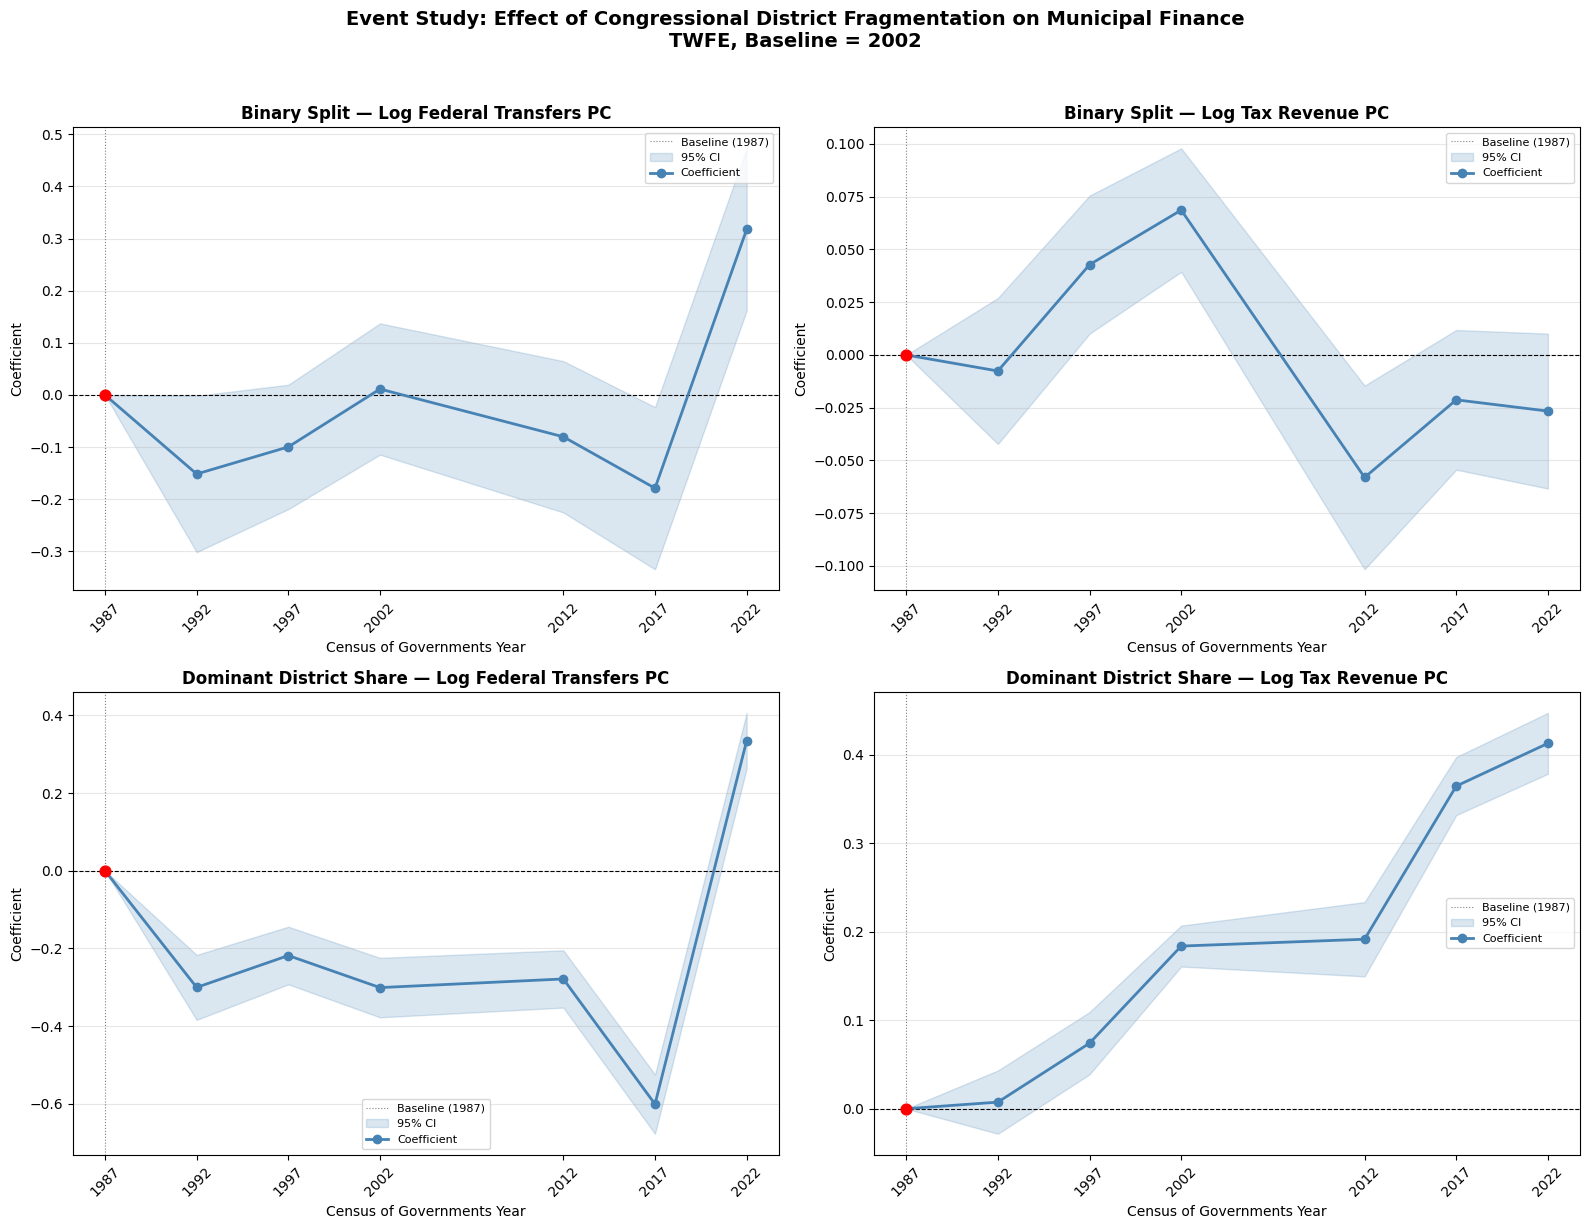


EVENT STUDY: Binary Split — Log Federal Transfers PC
Baseline: 1987
---------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi
---------------------------------------------------------------------------
  1987      0.0000      0.0000       nan       nan      0.0000      0.0000   <- baseline
  1992     -0.1515      0.0764     -1.98    0.0475     -0.3013     -0.0017  **
  1997     -0.0996      0.0608     -1.64    0.1017     -0.2188      0.0197  
  2002      0.0114      0.0642      0.18    0.8592     -0.1144      0.1372  
  2012     -0.0802      0.0740     -1.08    0.2786     -0.2252      0.0649  
  2017     -0.1787      0.0793     -2.25    0.0242     -0.3342     -0.0233  **
  2022      0.3174      0.0793      4.00    0.0001      0.1620      0.4728  ***

EVENT STUDY: Binary Split — Log Tax Revenue PC
Baseline: 1987
---------------------------------------------------------------------------
  Year 

In [70]:
# ============================================================
# FIGURE 1: Main Event Study, 2002 Baseline (updated with 1987)
# ============================================================

alt_baseline_yr = 1987

coef_alt_binary_transfers, _ = run_event_study(reg_df, "log_transfers_pc", "treatment_binary", alt_baseline_yr)
coef_alt_binary_tax,       _ = run_event_study(reg_df, "log_tax_pc",       "treatment_binary", alt_baseline_yr)
coef_alt_cont_transfers,   _ = run_event_study(reg_df, "log_transfers_pc", "treatment_cont",   alt_baseline_yr)
coef_alt_cont_tax,         _ = run_event_study(reg_df, "log_tax_pc",       "treatment_cont",   alt_baseline_yr)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_event_study(coef_alt_binary_transfers, "Binary Split — Log Federal Transfers PC",            axes[0,0], alt_baseline_yr)
plot_event_study(coef_alt_binary_tax,       "Binary Split — Log Tax Revenue PC",                  axes[0,1], alt_baseline_yr)
plot_event_study(coef_alt_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", axes[1,0], alt_baseline_yr)
plot_event_study(coef_alt_cont_tax,         "Dominant District Share — Log Tax Revenue PC",       axes[1,1], alt_baseline_yr)

fig.suptitle(
    "Event Study: Effect of Congressional District Fragmentation on Municipal Finance\n"
    "TWFE, Baseline = 2002",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("figure1_main_event_study_2002.png", dpi=300, bbox_inches='tight')
plt.show()

# Print coefficient tables so you can update the text
print_coef_table(coef_alt_binary_transfers, "Binary Split — Log Federal Transfers PC",            alt_baseline_yr)
print_coef_table(coef_alt_binary_tax,       "Binary Split — Log Tax Revenue PC",                  alt_baseline_yr)
print_coef_table(coef_alt_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", alt_baseline_yr)
print_coef_table(coef_alt_cont_tax,         "Dominant District Share — Log Tax Revenue PC",       alt_baseline_yr)

In [65]:
# Add a squared term to test for nonlinearity
reg_df['dist1_share_sq'] = reg_df['treatment_cont'] ** 2

coef_nonlinear, _ = run_event_study(
    reg_df, 'log_transfers_pc', 'dist1_share_sq', baseline_yr
)
print_coef_table(coef_nonlinear, 'Dist1 Share Squared — Log Federal Transfers PC', baseline_yr)


EVENT STUDY: Dist1 Share Squared — Log Federal Transfers PC
Baseline: 2012
---------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi
---------------------------------------------------------------------------
  1987      0.3078      0.0393      7.83    0.0000      0.2307      0.3849  ***
  1992     -0.0187      0.0391     -0.48    0.6330     -0.0954      0.0580  
  1997      0.0574      0.0313      1.84    0.0664     -0.0039      0.1186  *
  2002     -0.0273      0.0320     -0.85    0.3944     -0.0901      0.0355  
  2012      0.0000      0.0000       nan       nan      0.0000      0.0000   <- baseline
  2017     -0.3077      0.0309     -9.95    0.0000     -0.3683     -0.2471  ***
  2022      0.6011      0.0275     21.85    0.0000      0.5472      0.6550  ***


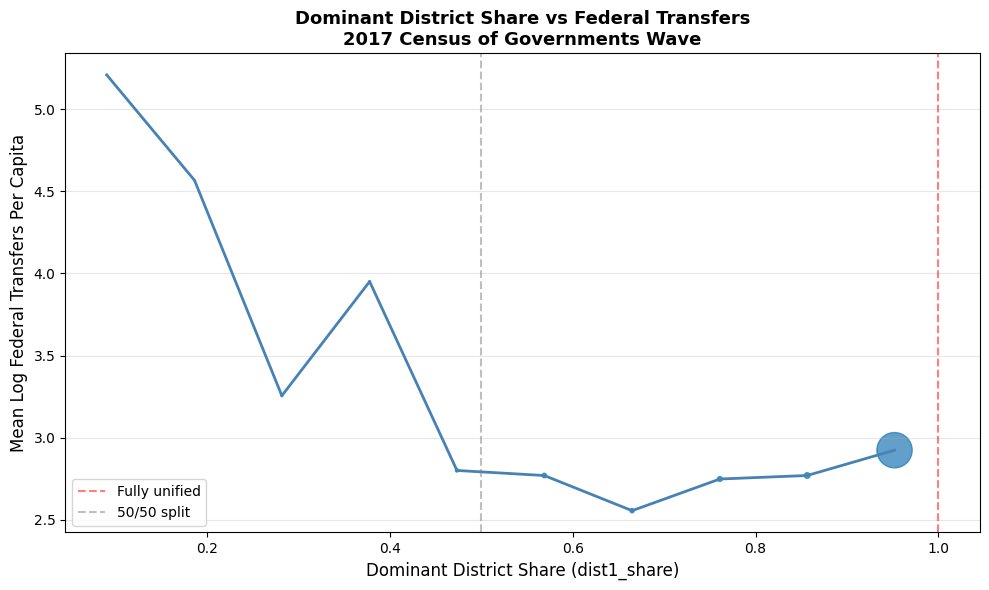

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Bin dist1_share into deciles and plot mean log transfers by bin
plot_df = reg_df[reg_df['year'] == 2017].copy()
plot_df = plot_df.dropna(subset=['treatment_cont', 'log_transfers_pc'])

plot_df['dist1_bin'] = pd.cut(plot_df['treatment_cont'], bins=10)

bin_means = plot_df.groupby('dist1_bin').agg(
    mean_transfers=('log_transfers_pc', 'mean'),
    count=('log_transfers_pc', 'count')
).reset_index()

bin_means['bin_mid'] = bin_means['dist1_bin'].apply(lambda x: x.mid)

plt.figure(figsize=(10, 6))
plt.scatter(bin_means['bin_mid'], bin_means['mean_transfers'], 
            s=bin_means['count']/10, alpha=0.7)
plt.plot(bin_means['bin_mid'], bin_means['mean_transfers'], 
         color='steelblue', linewidth=2)
plt.xlabel('Dominant District Share (dist1_share)', fontsize=12)
plt.ylabel('Mean Log Federal Transfers Per Capita', fontsize=12)
plt.title('Dominant District Share vs Federal Transfers\n2017 Census of Governments Wave', 
          fontsize=13, fontweight='bold')
plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='Fully unified')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='50/50 split')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('dist1_share_vs_transfers_2017.png', dpi=300, bbox_inches='tight')
plt.show()

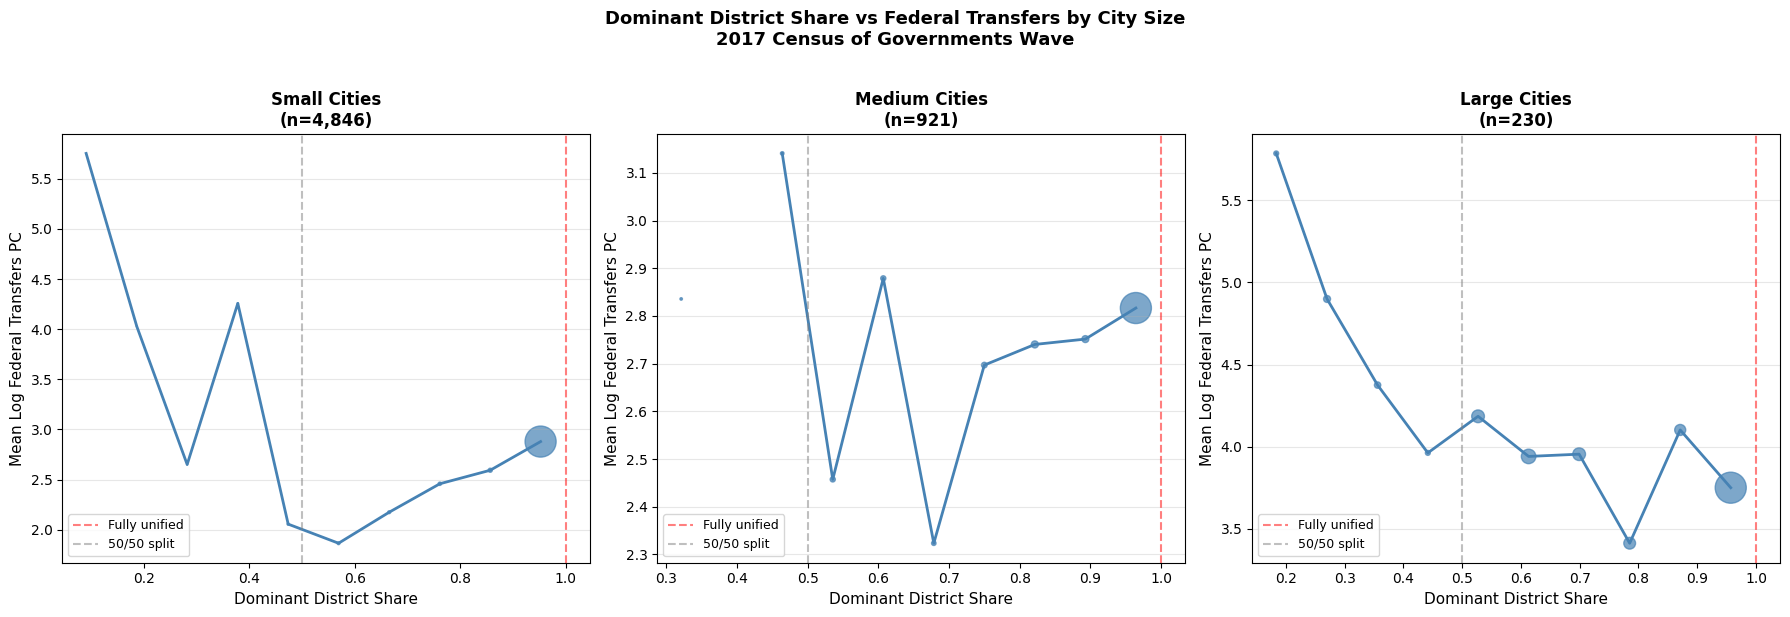

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for ax, bin_name in zip(axes, ['small', 'medium', 'large']):
    bin_df = reg_df[
        (reg_df['year'] == 2017) & 
        (reg_df['size_bin'] == bin_name)
    ].copy()
    bin_df = bin_df.dropna(subset=['treatment_cont', 'log_transfers_pc'])
    
    bin_df['dist1_bin'] = pd.cut(bin_df['treatment_cont'], bins=10)
    
    bin_means = bin_df.groupby('dist1_bin').agg(
        mean_transfers=('log_transfers_pc', 'mean'),
        count=('log_transfers_pc', 'count')
    ).reset_index()
    bin_means['bin_mid'] = bin_means['dist1_bin'].apply(lambda x: x.mid)
    bin_means = bin_means.dropna(subset=['bin_mid'])
    
    ax.scatter(bin_means['bin_mid'], bin_means['mean_transfers'],
               s=bin_means['count']/max(bin_means['count'])*500, 
               alpha=0.7, color='steelblue')
    ax.plot(bin_means['bin_mid'], bin_means['mean_transfers'],
            color='steelblue', linewidth=2)
    ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='Fully unified')
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='50/50 split')
    ax.set_xlabel('Dominant District Share', fontsize=11)
    ax.set_ylabel('Mean Log Federal Transfers PC', fontsize=11)
    ax.set_title(f'{bin_name.capitalize()} Cities\n(n={bin_df["PLACE_ID"].nunique():,})', 
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Dominant District Share vs Federal Transfers by City Size\n2017 Census of Governments Wave',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('dist1_share_vs_transfers_by_size_2017.png', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
import numpy as np

coefs = {
    "Binary transfers 2012": -0.0971,
    "Binary transfers 2017": -0.1959,
    "Binary transfers 2022":  0.3016,
    "Cont transfers 2012":    0.0167,
    "Cont transfers 2017":   -0.3061,
    "Cont transfers 2022":    0.6303,
    "Binary tax 2012":       -0.0627,
    "Binary tax 2017":       -0.0259,
    "Binary tax 2022":       -0.0295,
    "Cont tax 2012":          0.0095,
    "Cont tax 2017":          0.1834,
    "Cont tax 2022":          0.2343,
}

print(f"{'Specification':<25} {'Coef':>8} {'% Effect':>12}")
print("-"*48)
for label, coef in coefs.items():
    if "Cont" in label:
        pct = (np.exp(coef * 0.5) - 1) * 100
        note = "(0.5→1.0)"
    else:
        pct = (np.exp(coef) - 1) * 100
        note = "(split=1)"
    print(f"{label:<25} {coef:>8.4f} {pct:>10.1f}%  {note}")

Specification                 Coef     % Effect
------------------------------------------------
Binary transfers 2012      -0.0971       -9.3%  (split=1)
Binary transfers 2017      -0.1959      -17.8%  (split=1)
Binary transfers 2022       0.3016       35.2%  (split=1)
Cont transfers 2012         0.0167        0.8%  (0.5→1.0)
Cont transfers 2017        -0.3061      -14.2%  (0.5→1.0)
Cont transfers 2022         0.6303       37.0%  (0.5→1.0)
Binary tax 2012            -0.0627       -6.1%  (split=1)
Binary tax 2017            -0.0259       -2.6%  (split=1)
Binary tax 2022            -0.0295       -2.9%  (split=1)
Cont tax 2012               0.0095        0.5%  (0.5→1.0)
Cont tax 2017               0.1834        9.6%  (0.5→1.0)
Cont tax 2022               0.2343       12.4%  (0.5→1.0)


In [82]:
# ── Load and merge 1990 demographic controls ──────────────────────────────
import numpy as np

demo = pd.read_parquet("/Users/mayarabin/Desktop/Thesis Files/census_1990_joined.parquet")

demo["total_pop"] = pd.to_numeric(demo["NP1__total"], errors="coerce")

demo["pct_white"]    = pd.to_numeric(demo["NP6__white"], errors="coerce") / demo["total_pop"]
demo["pct_black"]    = pd.to_numeric(demo["NP6__black"], errors="coerce") / demo["total_pop"]
demo["pct_aian"]     = pd.to_numeric(demo["NP6__american_indian_eskimo_or_aleut"], errors="coerce") / demo["total_pop"]
demo["pct_asian"]    = pd.to_numeric(demo["NP6__asian_or_pacific_islander"], errors="coerce") / demo["total_pop"]
demo["pct_hispanic"] = (
    pd.to_numeric(demo["NP9__hispanic_origin_mexican"], errors="coerce") +
    pd.to_numeric(demo["NP9__hispanic_origin_puerto_rican"], errors="coerce") +
    pd.to_numeric(demo["NP9__hispanic_origin_cuban"], errors="coerce") +
    pd.to_numeric(demo["NP9__hispanic_origin_other_hispanic"], errors="coerce")
) / demo["total_pop"]

demo["pct_urban"]          = pd.to_numeric(demo["NP4__urban_inside_urbanized_area"], errors="coerce") / demo["total_pop"]
demo["pct_rural"]          = pd.to_numeric(demo["NP4__rural"], errors="coerce") / demo["total_pop"]
demo["pct_owner_occupied"] = pd.to_numeric(demo["NH3__owner_occupied"], errors="coerce") / pd.to_numeric(demo["NP3__total"], errors="coerce")
demo["pct_college"]        = pd.to_numeric(demo["NP57__bachelor_s_degree"], errors="coerce") / demo["total_pop"]
demo["log_median_income_1990"] = np.log(
    pd.to_numeric(demo["NP80A__median_household_income_in_1989"], errors="coerce").replace(0, np.nan)
)

DEMO_COLS = [
    "PLACE_ID",
    "pct_white", "pct_black", "pct_aian", "pct_asian", "pct_hispanic",
    "pct_urban", "pct_rural", "pct_owner_occupied",
    "pct_college", "log_median_income_1990",
]

demo_controls = demo[DEMO_COLS].copy()
panel = panel.merge(demo_controls, on="PLACE_ID", how="left")

print(f"Panel shape after demographic merge: {panel.shape}")
print(f"Rows with demographic controls: {panel['pct_white'].notna().sum():,}")

Panel shape after demographic merge: (225740, 93)
Rows with demographic controls: 180,057


In [83]:
# Check demographic match rate by year
print("=== Demographic match rate by wave ===")
for yr in sorted(panel['year'].unique()):
    sub = panel[panel['year'] == yr]
    matched = sub['pct_white'].notna().sum()
    total = len(sub)
    print(f"{yr}: {matched:,} / {total:,} ({matched/total*100:.1f}%)")

# Check if matched rows are systematically different
print("\n=== Split share among matched vs unmatched ===")
panel['has_demo'] = panel['pct_white'].notna()
print(panel.groupby('has_demo')['is_split'].mean())

=== Demographic match rate by wave ===
1987: 20,709 / 21,554 (96.1%)
1992: 25,316 / 35,771 (70.8%)
1997: 27,928 / 35,097 (79.6%)
2002: 23,609 / 29,283 (80.6%)
2012: 27,863 / 35,220 (79.1%)
2017: 27,559 / 34,746 (79.3%)
2022: 27,073 / 34,069 (79.5%)

=== Split share among matched vs unmatched ===
has_demo
False    0.020667
True     0.037038
Name: is_split, dtype: float64


In [85]:
def print_coef_table(coef_df, label, baseline_yr):
    from scipy.stats import norm
    print("\n" + "="*90)
    print(f"EVENT STUDY: {label}")
    print(f"Baseline: {baseline_yr}")
    print("-"*90)
    print(f"{'Year':>6}  {'Coef':>10}  {'SE':>10}  {'t':>8}  {'p':>8}  {'CI Lo':>10}  {'CI Hi':>10}  {'% Effect':>10}  {'Sig':>5}")
    print("-"*90)
    for _, row in coef_df.iterrows():
        yr   = int(row["year"])
        coef = row["coef"]
        se   = row["se"]
        t    = coef / se if se > 0 else np.nan
        p    = 2 * (1 - norm.cdf(abs(t))) if not np.isnan(t) else np.nan
        stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
        base = " <- baseline" if yr == baseline_yr else ""
        # % effect: for binary = (exp(coef)-1)*100, for continuous = (exp(coef*0.5)-1)*100
        pct = (np.exp(coef) - 1) * 100 if "Binary" in label else (np.exp(coef * 0.5) - 1) * 100
        print(f"  {yr:>4}  {coef:>10.4f}  {se:>10.4f}  {t:>8.2f}  {p:>8.4f}  {row['ci_lo']:>10.4f}  {row['ci_hi']:>10.4f}  {pct:>9.1f}%  {stars}{base}")
    print("="*90)

In [91]:
baseline_yr = 2002

coef_binary_transfers, _ = run_event_study(reg_df, "log_transfers_pc", "treatment_binary", baseline_yr)
coef_binary_tax,       _ = run_event_study(reg_df, "log_tax_pc",       "treatment_binary", baseline_yr)
coef_cont_transfers,   _ = run_event_study(reg_df, "log_transfers_pc", "treatment_cont",   baseline_yr)
coef_cont_tax,         _ = run_event_study(reg_df, "log_tax_pc",       "treatment_cont",   baseline_yr)

print_coef_table(coef_binary_transfers, "Binary Split — Log Federal Transfers PC", baseline_yr)
print_coef_table(coef_binary_tax,       "Binary Split — Log Tax Revenue PC",       baseline_yr)
print_coef_table(coef_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", baseline_yr)
print_coef_table(coef_cont_tax,         "Dominant District Share — Log Tax Revenue PC",       baseline_yr)


EVENT STUDY: Binary Split — Log Federal Transfers PC
Baseline: 2002
------------------------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi    % Effect    Sig
------------------------------------------------------------------------------------------
  1987     -0.2098      0.0978     -2.14    0.0320     -0.4016     -0.0181      -18.9%  **
  1992     -0.1690      0.0760     -2.22    0.0261     -0.3179     -0.0201      -15.5%  **
  1997     -0.1160      0.0598     -1.94    0.0523     -0.2332      0.0011      -11.0%  *
  2002      0.0000      0.0000       nan       nan      0.0000      0.0000        0.0%   <- baseline
  2012     -0.0971      0.0729     -1.33    0.1828     -0.2399      0.0457       -9.3%  
  2017     -0.1959      0.0781     -2.51    0.0121     -0.3489     -0.0428      -17.8%  **
  2022      0.3016      0.0785      3.84    0.0001      0.1477      0.4554       35.2%  ***

EVENT STU

In [92]:
# Check the demographic columns in reg_df
demo_check_cols = [
    "pct_white", "pct_black", "pct_aian", "pct_asian", "pct_hispanic",
    "pct_urban", "pct_rural", "pct_owner_occupied",
    "pct_college", "log_median_income_1990",
]

print("=== Demographic control summary stats ===")
print(reg_df[demo_check_cols].describe().round(3).to_string())

print("\n=== Sample values ===")
print(reg_df[demo_check_cols].head(5).to_string())

=== Demographic control summary stats ===
        pct_white   pct_black    pct_aian   pct_asian  pct_hispanic   pct_urban   pct_rural  pct_owner_occupied  pct_college  log_median_income_1990
count  180057.000  180057.000  180057.000  180057.000    180057.000  180057.000  180057.000          180057.000   180057.000              179998.000
mean        0.928       0.046       0.008       0.006         0.028       0.152       0.720               0.758        0.059                  10.102
std         0.144       0.129       0.038       0.017         0.091       0.353       0.440               0.119        0.048                   0.382
min         0.000       0.000       0.000       0.000         0.000       0.000       0.000               0.000        0.000                   8.517
25%         0.944       0.000       0.000       0.000         0.001       0.000       0.017               0.688        0.029                   9.867
50%         0.986       0.002       0.002       0.002         0.

In [93]:
# ── Cities continuously unified through 1980, 1990, 2000 redistricting ────
# Step 1: identify cities unified in ALL pre-2010 waves
unified_all_pre = None

for yr in [1987, 1992, 1997, 2002]:
    if yr not in reg_df['year'].unique():
        continue
    unified_yr = set(reg_df[
        (reg_df['year'] == yr) & 
        (reg_df['is_split'] == 0)
    ]['PLACE_ID'].unique())
    
    if unified_all_pre is None:
        unified_all_pre = unified_yr
    else:
        unified_all_pre = unified_all_pre & unified_yr

print(f"Cities unified in ALL pre-2010 waves: {len(unified_all_pre):,}")

# Step 2: get their 2012 split status
status_2012 = reg_df[
    (reg_df['year'] == 2012) &
    (reg_df['PLACE_ID'].isin(unified_all_pre))
][['PLACE_ID', 'is_split']].copy()
status_2012 = status_2012.rename(columns={'is_split': 'split_2012'})
status_2012['split_2012'] = pd.to_numeric(status_2012['split_2012'], errors='coerce')

print(f"Of those observed in 2012: {len(status_2012):,}")
print(f"Became split after 2010:   {(status_2012['split_2012']==1).sum():,}")
print(f"Stayed unified:            {(status_2012['split_2012']==0).sum():,}")

# Step 3: build clean DiD sample
clean_did_ids = status_2012.dropna()['PLACE_ID'].unique()
clean_did_df  = reg_df[reg_df['PLACE_ID'].isin(clean_did_ids)].copy()
clean_did_df  = clean_did_df.merge(
    status_2012[['PLACE_ID', 'split_2012']], 
    on='PLACE_ID', how='left'
)
clean_did_df['treated'] = clean_did_df['split_2012'].astype(float)

print(f"\nClean DiD sample: {len(clean_did_df):,} rows")
print(f"Unique cities: {clean_did_df['PLACE_ID'].nunique():,}")
print(f"Treated: {clean_did_df[clean_did_df['treated']==1]['PLACE_ID'].nunique():,}")
print(f"Control: {clean_did_df[clean_did_df['treated']==0]['PLACE_ID'].nunique():,}")

# Step 4: restrict to 2010 cycle waves only
clean_did_df = clean_did_df[clean_did_df['year'].isin([1997, 2002, 2012, 2017])].copy()

# Step 5: run event study
did_baseline = 2002
coef_clean_transfers, _ = run_event_study(clean_did_df, 'log_transfers_pc', 'treated', did_baseline)
coef_clean_tax,       _ = run_event_study(clean_did_df, 'log_tax_pc',       'treated', did_baseline)

print_coef_table(coef_clean_transfers, "Clean DiD — Continuously Unified → Split After 2010", did_baseline)
print_coef_table(coef_clean_tax,       "Clean DiD — Continuously Unified → Split After 2010 — Tax", did_baseline)

Cities unified in ALL pre-2010 waves: 15,817
Of those observed in 2012: 17,669
Became split after 2010:   225
Stayed unified:            17,444

Clean DiD sample: 175,439 rows
Unique cities: 15,673
Treated: 211
Control: 15,462

EVENT STUDY: Clean DiD — Continuously Unified → Split After 2010
Baseline: 2002
------------------------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi    % Effect    Sig
------------------------------------------------------------------------------------------
  1997      0.1390      0.2094      0.66    0.5067     -0.2713      0.5494        7.2%  
  2002      0.0000      0.0000       nan       nan      0.0000      0.0000        0.0%   <- baseline
  2012      0.1578      0.1791      0.88    0.3781     -0.1932      0.5089        8.2%  
  2017     -0.2642      0.1971     -1.34    0.1802     -0.6506      0.1222      -12.4%  

EVENT STUDY: Clean DiD — Continuously Unified →

Cities unified in ALL pre-2000 waves: 19,582
Of those observed in 2002: 17,679
Became split after 2000:   372
Stayed unified after 2000: 17,307

After stability requirement:
Stable cities total:    92,978
Stably split:           187
Stably unified:         92,791

Clean DiD sample:
Total rows:    7,897,210
Unique cities: 15,363
Treated:       86
Control:       15,277

EVENT STUDY: Clean DiD — Continuously Unified Pre-2000, Stable Post-2000 — Federal Transfers
Baseline: 1997
------------------------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi    % Effect    Sig
------------------------------------------------------------------------------------------
  1987      0.2422      1.0658      0.23    0.8202     -1.8468      2.3312       12.9%  
  1992      0.9745      0.6926      1.41    0.1595     -0.3831      2.3320       62.8%  
  1997      0.0000      0.0000       nan       nan      0.0000     

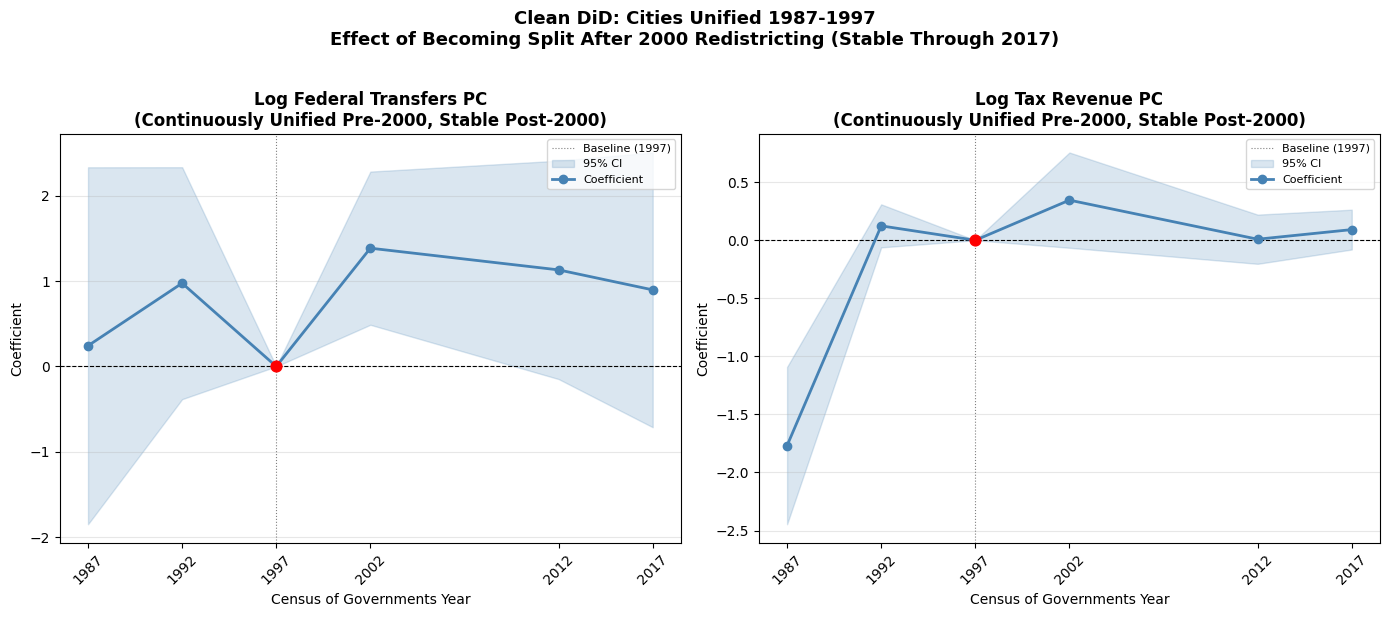

In [94]:
# ============================================================
# CLEAN DiD: Continuously Unified Pre-2000, Stable Post-2000
# ============================================================

# Step 1: cities unified in ALL pre-2000 waves
pre_waves = [1987, 1992, 1997]
unified_pre = None

for yr in pre_waves:
    if yr not in reg_df['year'].unique():
        continue
    unified_yr = set(reg_df[
        (reg_df['year'] == yr) &
        (reg_df['is_split'] == 0)
    ]['PLACE_ID'].unique())
    
    if unified_pre is None:
        unified_pre = unified_yr
    else:
        unified_pre = unified_pre & unified_yr

print(f"Cities unified in ALL pre-2000 waves: {len(unified_pre):,}")

# Step 2: get their 2002 split status (post 2000 redistricting)
status_2002 = reg_df[
    (reg_df['year'] == 2002) &
    (reg_df['PLACE_ID'].isin(unified_pre))
][['PLACE_ID', 'is_split']].copy()
status_2002 = status_2002.rename(columns={'is_split': 'split_2002'})
status_2002['split_2002'] = pd.to_numeric(status_2002['split_2002'], errors='coerce')

print(f"Of those observed in 2002: {len(status_2002):,}")
print(f"Became split after 2000:   {(status_2002['split_2002']==1).sum():,}")
print(f"Stayed unified after 2000: {(status_2002['split_2002']==0).sum():,}")

# Step 3: stability requirement — same status in 2012 AND 2017
status_2012 = reg_df[
    (reg_df['year'] == 2012) &
    (reg_df['PLACE_ID'].isin(status_2002['PLACE_ID']))
][['PLACE_ID', 'is_split']].rename(columns={'is_split': 'split_2012'})

status_2017 = reg_df[
    (reg_df['year'] == 2017) &
    (reg_df['PLACE_ID'].isin(status_2002['PLACE_ID']))
][['PLACE_ID', 'is_split']].rename(columns={'is_split': 'split_2017'})

# Merge all statuses together
status_all = status_2002.merge(status_2012, on='PLACE_ID', how='inner')
status_all = status_all.merge(status_2017, on='PLACE_ID', how='inner')

# Keep only cities where 2002, 2012, and 2017 status are all the same
status_all['stable'] = (
    (status_all['split_2002'] == status_all['split_2012']) &
    (status_all['split_2002'] == status_all['split_2017'])
)

stable_cities = status_all[status_all['stable']].copy()
print(f"\nAfter stability requirement:")
print(f"Stable cities total:    {len(stable_cities):,}")
print(f"Stably split:           {(stable_cities['split_2002']==1).sum():,}")
print(f"Stably unified:         {(stable_cities['split_2002']==0).sum():,}")

# Step 4: build DiD sample
clean_df = reg_df[
    reg_df['PLACE_ID'].isin(stable_cities['PLACE_ID']) &
    reg_df['year'].isin([1987, 1992, 1997, 2002, 2012, 2017])
].copy()

clean_df = clean_df.merge(
    stable_cities[['PLACE_ID', 'split_2002']],
    on='PLACE_ID', how='left'
)
clean_df['treated'] = clean_df['split_2002'].astype(float)

print(f"\nClean DiD sample:")
print(f"Total rows:    {len(clean_df):,}")
print(f"Unique cities: {clean_df['PLACE_ID'].nunique():,}")
print(f"Treated:       {clean_df[clean_df['treated']==1]['PLACE_ID'].nunique():,}")
print(f"Control:       {clean_df[clean_df['treated']==0]['PLACE_ID'].nunique():,}")

# Step 5: run event study with 1997 baseline
clean_baseline = 1997

coef_clean_transfers, _ = run_event_study(
    clean_df, 'log_transfers_pc', 'treated', clean_baseline
)
coef_clean_tax, _ = run_event_study(
    clean_df, 'log_tax_pc', 'treated', clean_baseline
)

print_coef_table(coef_clean_transfers, 
    "Clean DiD — Continuously Unified Pre-2000, Stable Post-2000 — Federal Transfers", 
    clean_baseline)
print_coef_table(coef_clean_tax, 
    "Clean DiD — Continuously Unified Pre-2000, Stable Post-2000 — Tax Revenue", 
    clean_baseline)

# Step 6: plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_event_study(coef_clean_transfers,
    "Log Federal Transfers PC\n(Continuously Unified Pre-2000, Stable Post-2000)",
    axes[0], clean_baseline)
plot_event_study(coef_clean_tax,
    "Log Tax Revenue PC\n(Continuously Unified Pre-2000, Stable Post-2000)",
    axes[1], clean_baseline)

fig.suptitle(
    "Clean DiD: Cities Unified 1987-1997\n"
    "Effect of Becoming Split After 2000 Redistricting (Stable Through 2017)",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

Cities split in ALL pre-2000 waves: 324
Of those observed in 2002: 324
Became unified after 2000: 111
Stayed split after 2000:   213

After stability requirement:
Stable cities total:      5,917
Stably unified post-2000: 117
Stably split post-2000:   5,800

Clean DiD sample (Split Pre-2000):
Total rows:    576,326
Unique cities: 202
Treated (reunified): 75
Control (stayed split): 127

EVENT STUDY: Clean DiD — Continuously Split Pre-2000, Stable Post-2000 — Federal Transfers
Baseline: 1997
------------------------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi    % Effect    Sig
------------------------------------------------------------------------------------------
  1987     -0.1475      0.6585     -0.22    0.8228     -1.4381      1.1432       -7.1%  
  1992     -0.2290      0.4547     -0.50    0.6146     -1.1203      0.6623      -10.8%  
  1997      0.0000      0.0000       nan       nan  

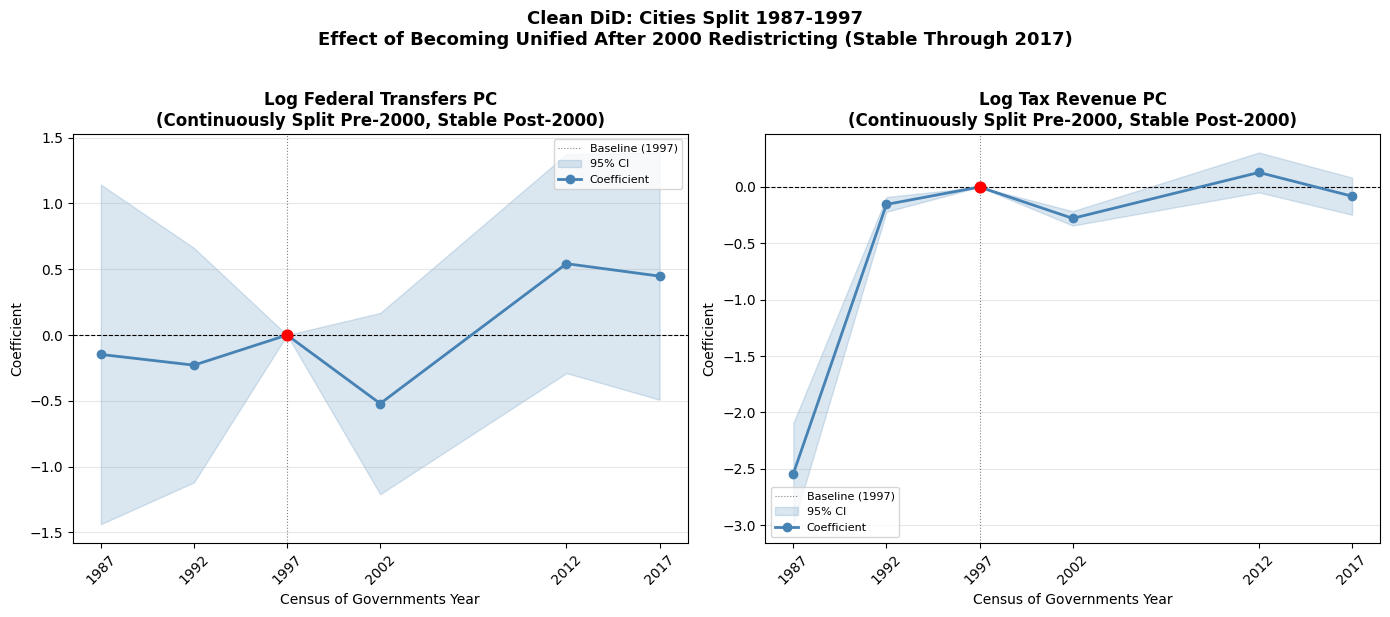

In [95]:
# ============================================================
# CLEAN DiD: Continuously SPLIT Pre-2000, Stable Post-2000
# ============================================================

# Step 1: cities SPLIT in ALL pre-2000 waves
pre_waves = [1987, 1992, 1997]
split_pre = None

for yr in pre_waves:
    if yr not in reg_df['year'].unique():
        continue
    split_yr = set(reg_df[
        (reg_df['year'] == yr) &
        (reg_df['is_split'] == 1)
    ]['PLACE_ID'].unique())
    
    if split_pre is None:
        split_pre = split_yr
    else:
        split_pre = split_pre & split_yr

print(f"Cities split in ALL pre-2000 waves: {len(split_pre):,}")

# Step 2: get their 2002 split status (post 2000 redistricting)
status_2002_s = reg_df[
    (reg_df['year'] == 2002) &
    (reg_df['PLACE_ID'].isin(split_pre))
][['PLACE_ID', 'is_split']].copy()
status_2002_s = status_2002_s.rename(columns={'is_split': 'split_2002'})
status_2002_s['split_2002'] = pd.to_numeric(status_2002_s['split_2002'], errors='coerce')

print(f"Of those observed in 2002: {len(status_2002_s):,}")
print(f"Became unified after 2000: {(status_2002_s['split_2002']==0).sum():,}")
print(f"Stayed split after 2000:   {(status_2002_s['split_2002']==1).sum():,}")

# Step 3: stability requirement — same status in 2012 AND 2017
status_2012_s = reg_df[
    (reg_df['year'] == 2012) &
    (reg_df['PLACE_ID'].isin(status_2002_s['PLACE_ID']))
][['PLACE_ID', 'is_split']].rename(columns={'is_split': 'split_2012'})

status_2017_s = reg_df[
    (reg_df['year'] == 2017) &
    (reg_df['PLACE_ID'].isin(status_2002_s['PLACE_ID']))
][['PLACE_ID', 'is_split']].rename(columns={'is_split': 'split_2017'})

# Merge all statuses
status_all_s = status_2002_s.merge(status_2012_s, on='PLACE_ID', how='inner')
status_all_s = status_all_s.merge(status_2017_s, on='PLACE_ID', how='inner')

# Keep only cities where 2002, 2012, and 2017 status are all the same
status_all_s['stable'] = (
    (status_all_s['split_2002'] == status_all_s['split_2012']) &
    (status_all_s['split_2002'] == status_all_s['split_2017'])
)

stable_cities_s = status_all_s[status_all_s['stable']].copy()
print(f"\nAfter stability requirement:")
print(f"Stable cities total:      {len(stable_cities_s):,}")
print(f"Stably unified post-2000: {(stable_cities_s['split_2002']==0).sum():,}")
print(f"Stably split post-2000:   {(stable_cities_s['split_2002']==1).sum():,}")

# Step 4: build DiD sample
clean_df_s = reg_df[
    reg_df['PLACE_ID'].isin(stable_cities_s['PLACE_ID']) &
    reg_df['year'].isin([1987, 1992, 1997, 2002, 2012, 2017])
].copy()

clean_df_s = clean_df_s.merge(
    stable_cities_s[['PLACE_ID', 'split_2002']],
    on='PLACE_ID', how='left'
)

# Treatment here is REUNIFICATION — becoming unified after being split
# So treated = became unified (split_2002 == 0)
# Control = stayed split (split_2002 == 1)
clean_df_s['treated'] = (clean_df_s['split_2002'] == 0).astype(float)

print(f"\nClean DiD sample (Split Pre-2000):")
print(f"Total rows:    {len(clean_df_s):,}")
print(f"Unique cities: {clean_df_s['PLACE_ID'].nunique():,}")
print(f"Treated (reunified): {clean_df_s[clean_df_s['treated']==1]['PLACE_ID'].nunique():,}")
print(f"Control (stayed split): {clean_df_s[clean_df_s['treated']==0]['PLACE_ID'].nunique():,}")

# Step 5: run event study with 1997 baseline
clean_baseline_s = 1997

coef_clean_s_transfers, _ = run_event_study(
    clean_df_s, 'log_transfers_pc', 'treated', clean_baseline_s
)
coef_clean_s_tax, _ = run_event_study(
    clean_df_s, 'log_tax_pc', 'treated', clean_baseline_s
)

print_coef_table(coef_clean_s_transfers,
    "Clean DiD — Continuously Split Pre-2000, Stable Post-2000 — Federal Transfers",
    clean_baseline_s)
print_coef_table(coef_clean_s_tax,
    "Clean DiD — Continuously Split Pre-2000, Stable Post-2000 — Tax Revenue",
    clean_baseline_s)

# Step 6: plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_event_study(coef_clean_s_transfers,
    "Log Federal Transfers PC\n(Continuously Split Pre-2000, Stable Post-2000)",
    axes[0], clean_baseline_s)
plot_event_study(coef_clean_s_tax,
    "Log Tax Revenue PC\n(Continuously Split Pre-2000, Stable Post-2000)",
    axes[1], clean_baseline_s)

fig.suptitle(
    "Clean DiD: Cities Split 1987-1997\n"
    "Effect of Becoming Unified After 2000 Redistricting (Stable Through 2017)",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

In [104]:
# ── Calculate split status transitions across redistricting cycles ─────────
# Each redistricting cycle is measured as the transition between the
# COG wave immediately before and immediately after redistricting

cycles = [
    ("1980 Redistricting", None, 1987),      # no pre-period for 1980
    ("1990 Redistricting", 1987, 1992),
    ("2000 Redistricting", 1997, 2002),
    ("2010 Redistricting", 2002, 2012),
    ("2020 Redistricting", 2017, 2022),
]

print(f"{'Cycle':<25} {'U→S':>8} {'S→U':>8} {'No Chg U':>10} {'No Chg S':>10} {'Total':>8}")
print("-"*75)

for cycle_name, pre_yr, post_yr in cycles:
    if pre_yr is None:
        # For 1980 — just count total municipalities in the post wave
        post_only = reg_df[reg_df['year'] == post_yr][['PLACE_ID', 'is_split']].copy()
        post_only['is_split'] = pd.to_numeric(post_only['is_split'], errors='coerce')
        post_only = post_only.dropna(subset=['is_split'])
        total_1980 = len(post_only)
        print(f"{cycle_name:<25} {'—':>8} {'—':>8} {'—':>10} {'—':>10} {total_1980:>8,}")
        continue

    # Get pre and post status for places observed in both waves
    pre = reg_df[reg_df['year'] == pre_yr][['PLACE_ID', 'is_split']].copy()
    pre = pre.rename(columns={'is_split': 'pre_split'})
    pre['pre_split'] = pd.to_numeric(pre['pre_split'], errors='coerce')

    post = reg_df[reg_df['year'] == post_yr][['PLACE_ID', 'is_split']].copy()
    post = post.rename(columns={'is_split': 'post_split'})
    post['post_split'] = pd.to_numeric(post['post_split'], errors='coerce')

    # Merge on PLACE_ID — only keep places observed in both waves
    merged = pre.merge(post, on='PLACE_ID', how='inner')
    merged = merged.dropna(subset=['pre_split', 'post_split'])

    unified_to_split  = ((merged['pre_split'] == 0) & (merged['post_split'] == 1)).sum()
    split_to_unified  = ((merged['pre_split'] == 1) & (merged['post_split'] == 0)).sum()
    no_change_unified = ((merged['pre_split'] == 0) & (merged['post_split'] == 0)).sum()
    no_change_split   = ((merged['pre_split'] == 1) & (merged['post_split'] == 1)).sum()
    total             = len(merged)

    print(f"{cycle_name:<25} {unified_to_split:>8,} {split_to_unified:>8,} {no_change_unified:>10,} {no_change_split:>10,} {total:>8,}")




Cycle                          U→S      S→U   No Chg U   No Chg S    Total
---------------------------------------------------------------------------
1980 Redistricting               —        —          —          —   21,554
1990 Redistricting             656      416     21,900        389   23,361
2000 Redistricting             752      627     29,260        789   31,428
2010 Redistricting             515      804     29,436        751   31,506
2020 Redistricting             581      594     36,887        941   39,003


In [106]:
# ── Calculate dollar amounts for Introduction ─────────────────────────────

# Average federal transfers per capita for unified municipalities in 2017
unified_2017 = reg_df[
    (reg_df['year'] == 2017) & 
    (reg_df['is_split'] == 0)
]['federal_transfers_pc'].dropna()

mean_transfers = unified_2017.mean()
print(f"Mean federal transfers pc (unified, 2017): ${mean_transfers:.2f}")

# Binary coefficient implies 17.8% fewer for split cities
pct_effect_binary = (1 - 0.178)
dollar_gap = mean_transfers * 0.178
print(f"Dollar gap per capita per year: ${dollar_gap:.2f}")

# Cumulated over a decade (2 COG waves)
cumulated = dollar_gap * 10
print(f"Cumulated over decade: ${cumulated:.2f}")

# For a 100,000 person city
city_size = 100000
city_gap = dollar_gap * city_size / 1_000_000
print(f"For 100,000 person city per year: ${city_gap:.2f}M")
city_decade = city_gap * 10
print(f"For 100,000 person city over decade: ${city_decade:.2f}M")

# Fall River specifically — 90,000 residents
fall_river_pop = 90000
fall_river_gap = dollar_gap * fall_river_pop / 1_000_000
print(f"\nFall River (90,000 pop) per year: ${fall_river_gap:.2f}M")
fall_river_decade = fall_river_gap * 10
print(f"Fall River over decade: ${fall_river_decade:.2f}M")


# ── Diagnose the low mean ─────────────────────────────────────────────────
print("=== Federal transfers pc distribution (unified, 2017) ===")
print(unified_2017.describe())

print(f"\nZero values: {(unified_2017 == 0).sum():,}")
print(f"Non-zero values: {(unified_2017 > 0).sum():,}")

# Try non-zero only
nonzero = unified_2017[unified_2017 > 0]
print(f"\nMean (non-zero only): ${nonzero.mean():.2f}")
print(f"Median (non-zero only): ${nonzero.median():.2f}")

# Check if log was applied somewhere
print("\n=== log_transfers_pc distribution (unified, 2017) ===")
log_unified = reg_df[
    (reg_df['year'] == 2017) & 
    (reg_df['is_split'] == 0)
]['log_transfers_pc'].dropna()
print(log_unified.describe())
print(f"\nExp of mean log: ${log_unified.mean().__float__().__format__('.2f')} log points")
print(f"Exp of mean: ${(2.718**log_unified.mean()):.2f}")

Mean federal transfers pc (unified, 2017): $27.17
Dollar gap per capita per year: $4.84
Cumulated over decade: $48.36
For 100,000 person city per year: $0.48M
For 100,000 person city over decade: $4.84M

Fall River (90,000 pop) per year: $0.44M
Fall River over decade: $4.35M
=== Federal transfers pc distribution (unified, 2017) ===
count    28198.000000
mean        27.170817
std        253.485520
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      19978.021978
Name: federal_transfers_pc, dtype: float64

Zero values: 21,596
Non-zero values: 6,602

Mean (non-zero only): $116.05
Median (non-zero only): $21.15

=== log_transfers_pc distribution (unified, 2017) ===
count    6602.000000
mean        2.936210
std         1.958675
min        -4.195200
25%         1.645200
50%         3.051789
75%         4.256481
max         9.902388
Name: log_transfers_pc, dtype: float64

Exp of mean log: $2.94 log points
Exp of mean: $18.84


In [109]:
# ── Correct dollar calculations using non-zero municipalities only ─────────
nonzero_unified_2017 = reg_df[
    (reg_df['year'] == 2017) & 
    (reg_df['is_split'] == 0) &
    (reg_df['federal_transfers_pc'] > 0)
]['federal_transfers_pc'].dropna()

mean_transfers = nonzero_unified_2017.mean()
median_transfers = nonzero_unified_2017.median()

print(f"Mean federal transfers pc (non-zero unified, 2017): ${mean_transfers:.2f}")
print(f"Median federal transfers pc (non-zero unified, 2017): ${median_transfers:.2f}")

# Use binary coefficient 17.8% effect
pct_effect = 0.178
dollar_gap_mean   = mean_transfers * pct_effect
dollar_gap_median = median_transfers * pct_effect

print(f"\nUsing MEAN:")
print(f"Dollar gap per capita per year: ${dollar_gap_mean:.2f}")
print(f"Cumulated over decade: ${dollar_gap_mean * 10:.2f}")
print(f"100,000 person city per year: ${dollar_gap_mean * 100000 / 1_000_000:.2f}M")
print(f"100,000 person city over decade: ${dollar_gap_mean * 100000 * 10 / 1_000_000:.2f}M")

print(f"\nUsing MEDIAN:")
print(f"Dollar gap per capita per year: ${dollar_gap_median:.2f}")
print(f"Cumulated over decade: ${dollar_gap_median * 10:.2f}")
print(f"100,000 person city per year: ${dollar_gap_median * 100000 / 1_000_000:.2f}M")
print(f"100,000 person city over decade: ${dollar_gap_median * 100000 * 10 / 1_000_000:.2f}M")

print(f"\nFall River (90,000 pop) using MEAN:")
print(f"Per year: ${dollar_gap_mean * 90000 / 1_000_000:.2f}M")
print(f"Over decade: ${dollar_gap_mean * 90000 * 10 / 1_000_000:.2f}M")

print(f"\nFall River (90,000 pop) using MEDIAN:")
print(f"Per year: ${dollar_gap_median * 90000 / 1_000_000:.2f}M")
print(f"Over decade: ${dollar_gap_median * 90000 * 10 / 1_000_000:.2f}M")

Mean federal transfers pc (non-zero unified, 2017): $116.05
Median federal transfers pc (non-zero unified, 2017): $21.15

Using MEAN:
Dollar gap per capita per year: $20.66
Cumulated over decade: $206.57
100,000 person city per year: $2.07M
100,000 person city over decade: $20.66M

Using MEDIAN:
Dollar gap per capita per year: $3.77
Cumulated over decade: $37.65
100,000 person city per year: $0.38M
100,000 person city over decade: $3.77M

Fall River (90,000 pop) using MEAN:
Per year: $1.86M
Over decade: $18.59M

Fall River (90,000 pop) using MEDIAN:
Per year: $0.34M
Over decade: $3.39M


In [110]:
# ── Verify all key numbers cited in thesis text ───────────────────────────
baseline_yr = 2002

coef_binary_transfers, _ = run_event_study(reg_df, "log_transfers_pc", "treatment_binary", baseline_yr)
coef_binary_tax,       _ = run_event_study(reg_df, "log_tax_pc",       "treatment_binary", baseline_yr)
coef_cont_transfers,   _ = run_event_study(reg_df, "log_transfers_pc", "treatment_cont",   baseline_yr)
coef_cont_tax,         _ = run_event_study(reg_df, "log_tax_pc",       "treatment_cont",   baseline_yr)

print("=== BINARY TRANSFERS ===")
print_coef_table(coef_binary_transfers, "Binary Split — Log Federal Transfers PC", baseline_yr)

print("=== BINARY TAX ===")
print_coef_table(coef_binary_tax, "Binary Split — Log Tax Revenue PC", baseline_yr)

print("=== CONTINUOUS TRANSFERS ===")
print_coef_table(coef_cont_transfers, "Dominant District Share — Log Federal Transfers PC", baseline_yr)

print("=== CONTINUOUS TAX ===")
print_coef_table(coef_cont_tax, "Dominant District Share — Log Tax Revenue PC", baseline_yr)

=== BINARY TRANSFERS ===

EVENT STUDY: Binary Split — Log Federal Transfers PC
Baseline: 2002
------------------------------------------------------------------------------------------
  Year        Coef          SE         t         p       CI Lo       CI Hi    % Effect    Sig
------------------------------------------------------------------------------------------
  1987     -0.2098      0.0978     -2.14    0.0320     -0.4016     -0.0181      -18.9%  **
  1992     -0.1690      0.0760     -2.22    0.0261     -0.3179     -0.0201      -15.5%  **
  1997     -0.1160      0.0598     -1.94    0.0523     -0.2332      0.0011      -11.0%  *
  2002      0.0000      0.0000       nan       nan      0.0000      0.0000        0.0%   <- baseline
  2012     -0.0971      0.0729     -1.33    0.1828     -0.2399      0.0457       -9.3%  
  2017     -0.1959      0.0781     -2.51    0.0121     -0.3489     -0.0428      -17.8%  **
  2022      0.3016      0.0785      3.84    0.0001      0.1477      0.4554   

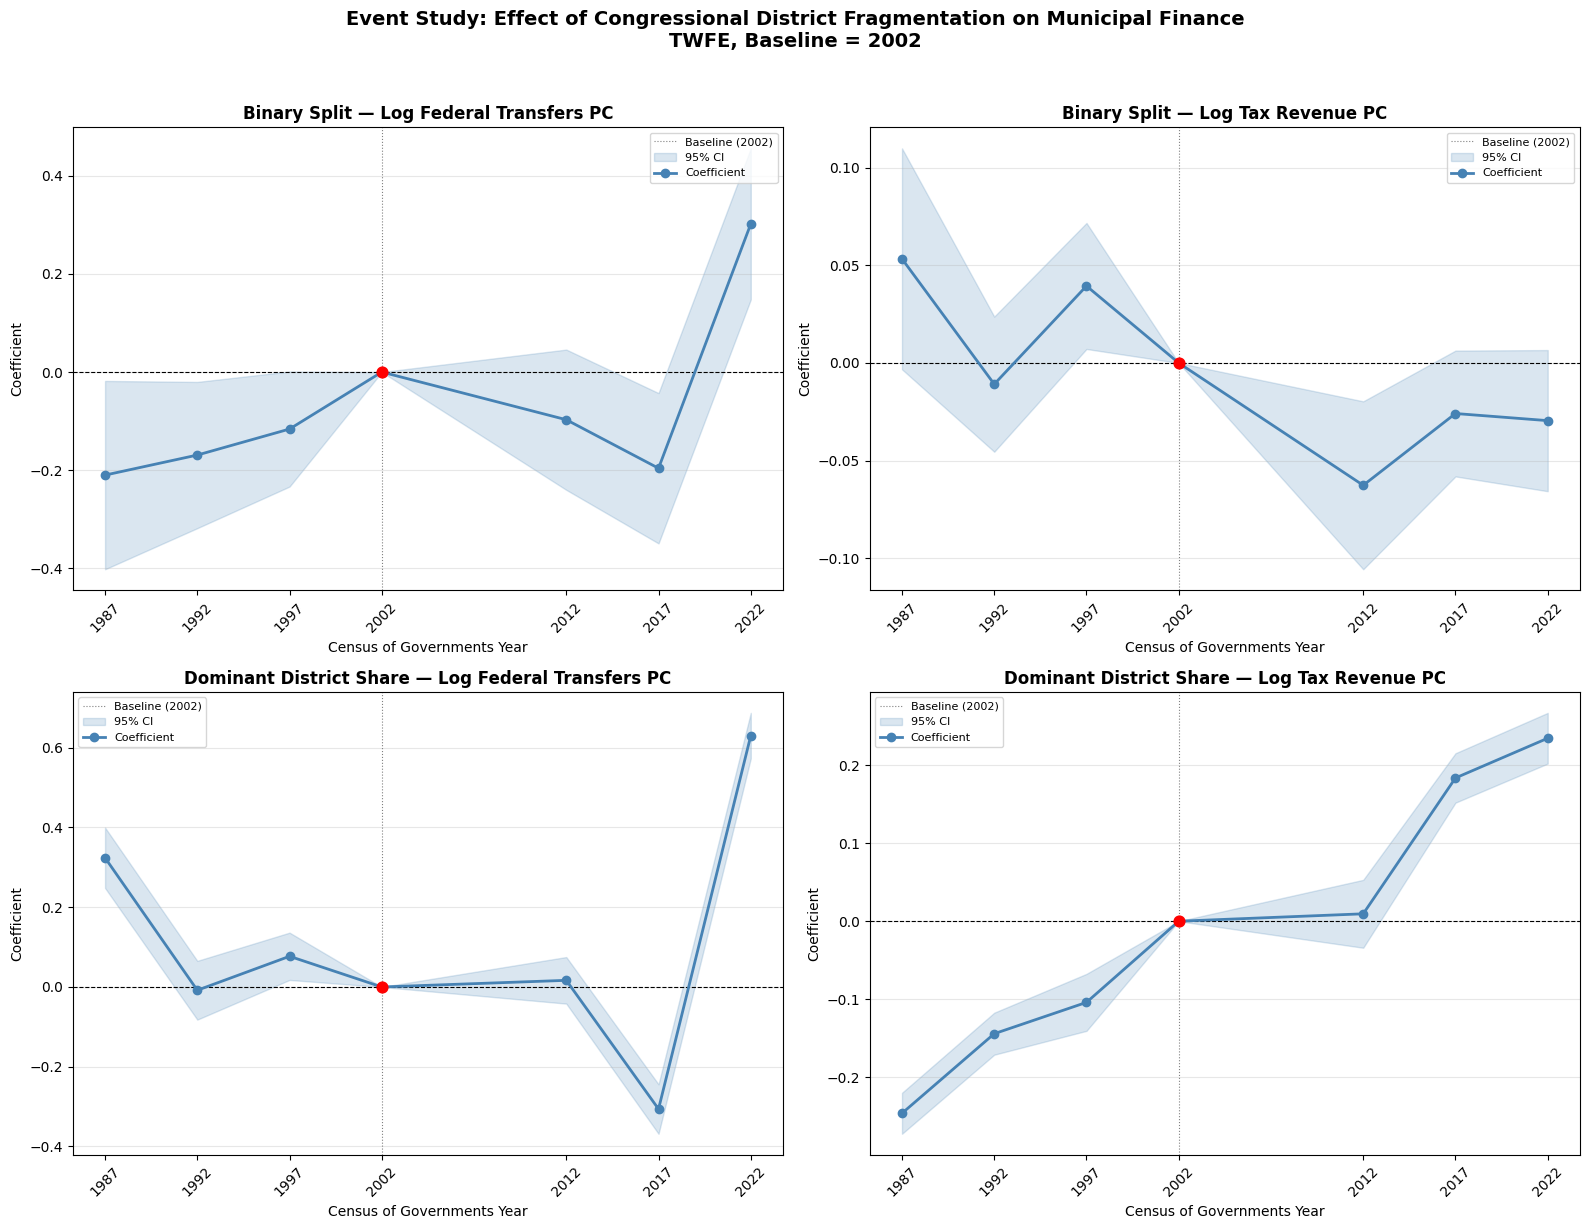

In [115]:
baseline_yr = 2002

coef_binary_transfers, _ = run_event_study(reg_df, "log_transfers_pc", "treatment_binary", baseline_yr)
coef_binary_tax,       _ = run_event_study(reg_df, "log_tax_pc",       "treatment_binary", baseline_yr)
coef_cont_transfers,   _ = run_event_study(reg_df, "log_transfers_pc", "treatment_cont",   baseline_yr)
coef_cont_tax,         _ = run_event_study(reg_df, "log_tax_pc",       "treatment_cont",   baseline_yr)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

plot_event_study(coef_binary_transfers, "Binary Split — Log Federal Transfers PC",       axes[0,0], baseline_yr)
plot_event_study(coef_binary_tax,       "Binary Split — Log Tax Revenue PC",              axes[0,1], baseline_yr)
plot_event_study(coef_cont_transfers,   "Dominant District Share — Log Federal Transfers PC", axes[1,0], baseline_yr)
plot_event_study(coef_cont_tax,         "Dominant District Share — Log Tax Revenue PC",   axes[1,1], baseline_yr)

fig.suptitle(
    "Event Study: Effect of Congressional District Fragmentation on Municipal Finance\n"
    "TWFE, Baseline = 2002",
    fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("figure1_main_event_study.png", dpi=300, bbox_inches='tight')
plt.show()